#A.Exploratory Data Analysis (EDA)

#Importing necessary Libraries

In [442]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Importing necessary libraries

In [443]:
#reading csv as a data frame
df = pd.read_csv("/content/Silver_Data.csv")

In [444]:
df.head()
#printing first few rows

,Unnamed: 0,Show,Season,Air_Date,Week_Number,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
0,0,Show2,1,2020-10-05,5,0,PreLaunch,8721.066697,10465.280036,3488.426679,44768143,66845.590114,45352.467143,0,0
1,1,Show4,3,2022-10-15,6,1,Premiere,3524.911498,NaN,8812.278744,38186541,83713.735201,58420.934286,0,0
2,2,Show2,4,2023-10-27,8,3,Regular,6964.236436,2785.694575,8357.083724,30178358,63736.233023,45484.814286,0,0
3,3,Show7,1,2024-03-24,11,6,Regular,NaN,7625.926405,6354.938671,27538068,45117.211196,31663.720000,0,0
4,4,Show5,1,2023-08-14,10,5,Regular,7466.359494,2488.786498,6221.966245,28621044,87525.734172,60840.965714,0,0


#Data type Check

In [445]:
df.info()
# Data overview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3143 entries, 0 to 3142
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        3143 non-null   int64  
 1   Show              3143 non-null   object 
 2   Season            3143 non-null   int64  
 3   Air_Date          3143 non-null   object 
 4   Week_Number       3143 non-null   int64  
 5   Episode_Number    3143 non-null   int64  
 6   Episode_Type      3143 non-null   object 
 7   Network_TV_Spend  3110 non-null   float64
 8   Cable_TV_Spend    3112 non-null   float64
 9   Digital_Spend     3109 non-null   float64
 10  Impressions       3143 non-null   int64  
 11  True_Viewership   3111 non-null   float64
 12  Revenue           3109 non-null   float64
 13  Holiday           3143 non-null   int64  
 14  LeadIn_Bonus      3143 non-null   int64  
dtypes: float64(5), int64(7), object(3)
memory usage: 368.4+ KB


#Changing Dtype for Air_Date

In [446]:
df["Air_Date"] = pd.to_datetime(df["Air_Date"])
#Data Type Conversion

#Quick Sanity Check

In [447]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3143 entries, 0 to 3142
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Unnamed: 0        3143 non-null   int64         
 1   Show              3143 non-null   object        
 2   Season            3143 non-null   int64         
 3   Air_Date          3143 non-null   datetime64[ns]
 4   Week_Number       3143 non-null   int64         
 5   Episode_Number    3143 non-null   int64         
 6   Episode_Type      3143 non-null   object        
 7   Network_TV_Spend  3110 non-null   float64       
 8   Cable_TV_Spend    3112 non-null   float64       
 9   Digital_Spend     3109 non-null   float64       
 10  Impressions       3143 non-null   int64         
 11  True_Viewership   3111 non-null   float64       
 12  Revenue           3109 non-null   float64       
 13  Holiday           3143 non-null   int64         
 14  LeadIn_Bonus      3143 n

#Checking Null Values

In [448]:
df.isnull().sum()
# Missing values count

,0
Unnamed: 0,0
Show,0
Season,0
Air_Date,0
Week_Number,0
Episode_Number,0
Episode_Type,0
Network_TV_Spend,33
Cable_TV_Spend,31
Digital_Spend,34


#As Per the initial observation , there are are Null Values in Spend Colums, Viewership and Revenue

In [449]:
# Drop artificial index column
df = df.drop(columns=["Unnamed: 0"])

#Checking the existence of duplicate rows

In [450]:
df.duplicated().sum()
# Duplicate rows count

np.int64(187)

#Dropping Duplicates

In [451]:

df = df.drop_duplicates()
#dropping duplicate

#Verification

In [452]:
df.duplicated().sum()
#duplicate values verification

np.int64(0)

#Statistical Summary

In [453]:
df.describe()
# Summary statistics

,Season,Air_Date,Week_Number,Episode_Number,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
count,2956.000000,2956,2956.000000,2956.000000,2923.000000,2925.000000,2922.000000,2.956000e+03,2924.000000,2922.000000,2956.000000,2956.000000
mean,2.573072,2023-04-08 00:33:36.779431936,8.000000,3.667456,10868.618934,10785.744990,11714.548671,5.864916e+07,126954.809726,89118.114107,0.065291,0.057172
min,1.000000,2020-09-06 00:00:00,1.000000,0.000000,1737.959827,2158.075740,2039.800603,1.795892e+07,33054.486655,23264.130000,0.000000,0.000000
25%,1.000000,2021-11-24 00:00:00,4.000000,0.000000,5257.310701,6172.576004,7247.001977,3.953125e+07,70663.681163,49587.802857,0.000000,0.000000
50%,2.000000,2023-09-10 00:00:00,8.000000,3.000000,9343.821830,8849.285445,10635.495023,5.821572e+07,106877.147574,75751.057143,0.000000,0.000000
75%,4.000000,2024-07-29 06:00:00,12.000000,7.000000,15932.598611,15404.942480,15881.544689,7.399226e+07,191611.487094,133443.578571,0.000000,0.000000
max,5.000000,2025-04-26 00:00:00,15.000000,10.000000,29201.760073,27829.401203,27665.920853,1.178540e+08,261690.322671,181578.090000,1.000000,1.000000
std,1.401862,NaN,4.323078,3.497744,6449.643143,6043.415234,5678.399886,2.215967e+07,62986.274330,44191.591217,0.247080,0.232210


#Distribution Checks

#Distribution of Marketing Spend

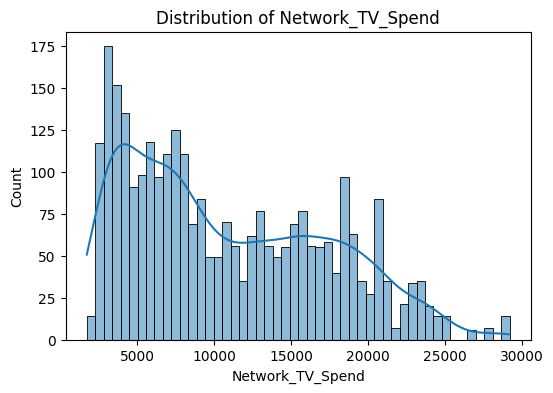

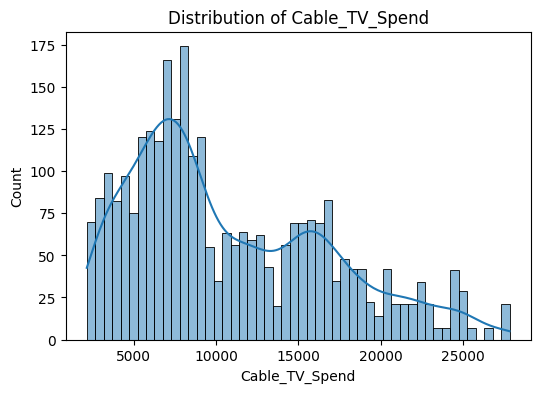

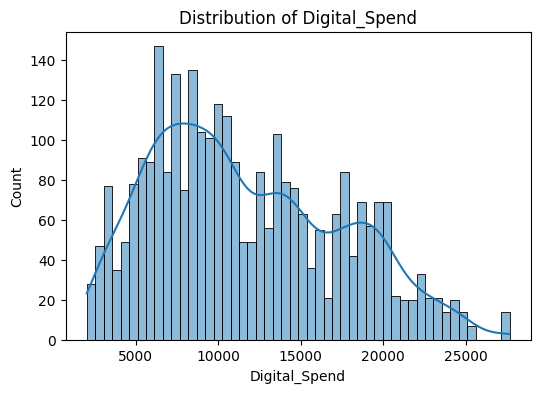

In [454]:
# Spend distribution plots
spend_cols = ["Network_TV_Spend","Cable_TV_Spend","Digital_Spend"]

for col in spend_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

###All three marketing channels (Network TV, Cable TV, and Digital) show positively skewed spend distributions, indicating that most episodes receive moderate advertising budgets while a smaller number of strategically important campaign weeks experience significantly higher marketing investment.

#Impressions Distribtion

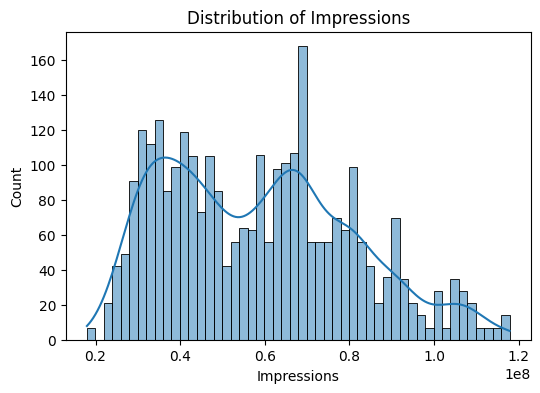

In [455]:
plt.figure(figsize=(6,4))
sns.histplot(df["Impressions"], bins=50, kde=True)
plt.title("Distribution of Impressions")
plt.show()
# Impressions distribution

###Impressions exhibit a positively skewed and multi-modal distribution, indicating that most campaign weeks achieve moderate audience reach, while a smaller number of weeks generate significantly higher exposure. The presence of multiple peaks suggests variations in campaign intensity across weeks, likely driven by differences in marketing spend and episode importance. This pattern highlights uneven campaign reach and the use of strategic promotional bursts rather than uniform media allocation.

#True Viewership Distribution

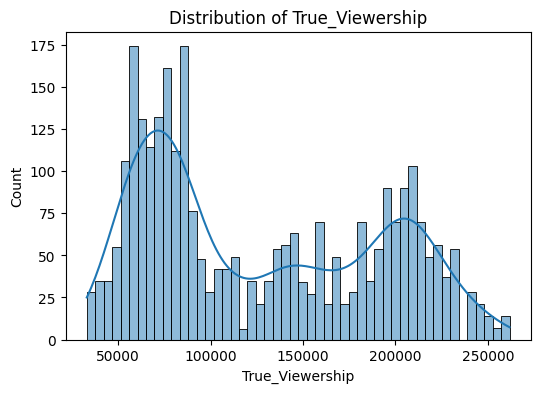

In [456]:
plt.figure(figsize=(6,4))
sns.histplot(df["True_Viewership"], bins=50, kde=True)
plt.title("Distribution of True_Viewership")
plt.show()
# Viewership distribution

###True viewership exhibits a positively skewed and multi-modal distribution, indicating that audience engagement varies significantly across episodes rather than following a uniform pattern. The presence of multiple peaks suggests differing performance levels driven by factors such as episode importance, marketing support, seasonal timing, and inherent show popularity. The wide spread in viewership highlights the combined influence of baseline demand and promotional activity on audience outcomes.

#Revenue Distribution

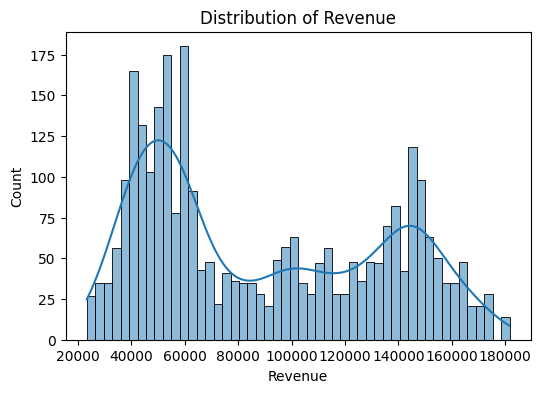

In [457]:
plt.figure(figsize=(6,4))
sns.histplot(df["Revenue"], bins=50, kde=True)
plt.title("Distribution of Revenue")
plt.show()
# Revenue distribution

###True Vieweship and Revenue exhibit similar shapes. Since revenue is directly derived from viewership through a fix monetization rate per viewer.

In [458]:
df[["Network_TV_Spend","Cable_TV_Spend","Digital_Spend"]].skew()
# Spend skewness check

,0
Network_TV_Spend,0.531136
Cable_TV_Spend,0.729155
Digital_Spend,0.458566


#Positive skewness across all channels indicates concentrated media bursts during select campaign weeks rather than uniform budget allocation.

#Outlier Check in spends across channels

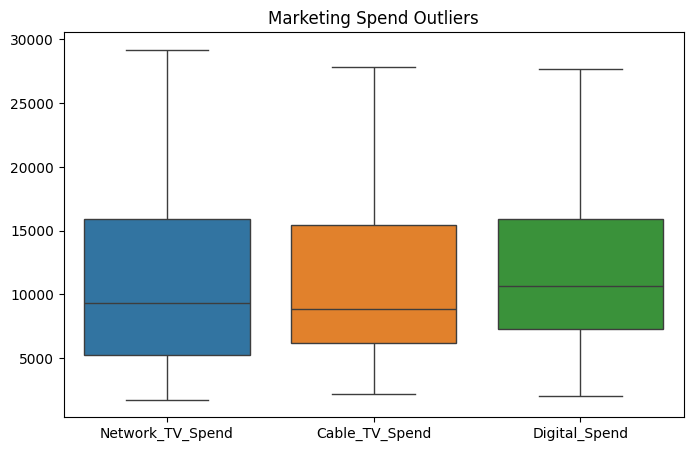

In [459]:
# Spend outliers check
plt.figure(figsize=(8,5))
sns.boxplot(data=df[spend_cols])
plt.title("Marketing Spend Outliers")
plt.show()

###The boxplot indicates that marketing spend across Network TV, Cable TV, and Digital channels shows moderate variability with comparable median spending levels. While higher spend values are present, extreme outliers are limited, suggesting that most campaign weeks operate within a controlled budget range. The slightly wider spread in Digital spend implies slightly greater variability in allocation compared to traditional TV channels.

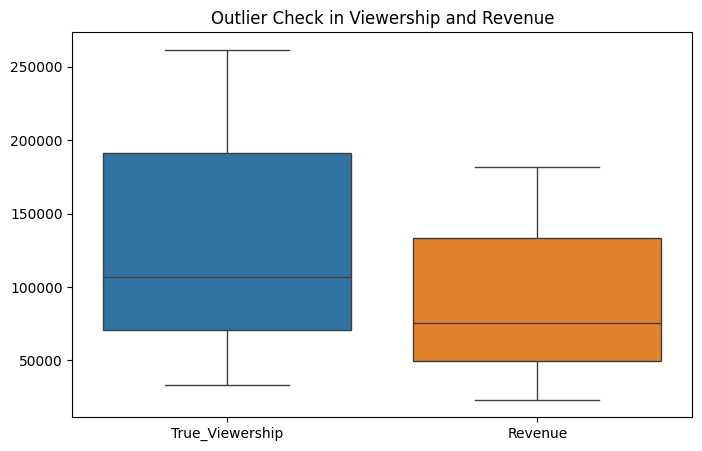

In [460]:
# Viewership revenue outliers
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["True_Viewership","Revenue"]])
plt.title("Outlier Check in Viewership and Revenue")
plt.show()

###Revenue closely follows viewership trends, indicating that audience reach is the primary driver of monetization. Strategic marketing efforts that boost viewership during key episodes directly translate into higher revenue outcomes.

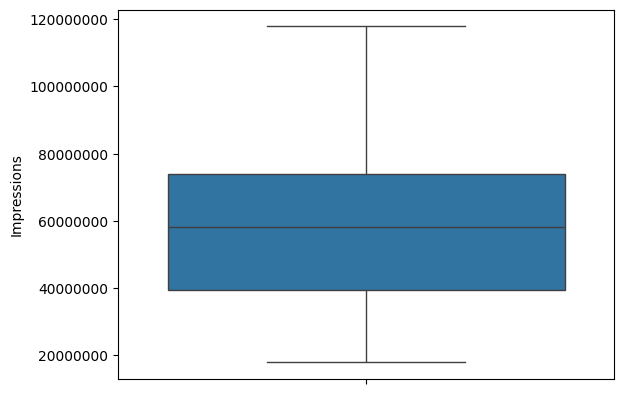

In [461]:
#Impressions Outlier Check
ax = sns.boxplot(data=df["Impressions"])
ax.ticklabel_format(style='plain', axis='y')

#This tells us: Huge variation in campaign reach, Media bursts likely

#Boxplot: Revenue vs Holiday

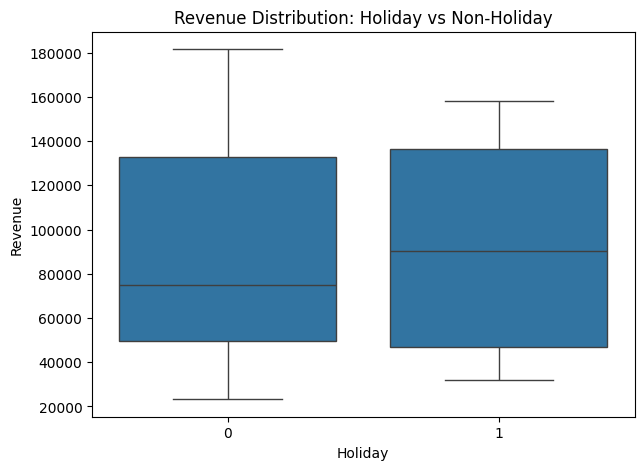

In [462]:
# Holiday revenue comparison
plt.figure(figsize=(7,5))
sns.boxplot(x="Holiday", y="Revenue", data=df)
plt.title("Revenue Distribution: Holiday vs Non-Holiday")
plt.show()

###Holiday episodes tend to generate higher median revenue but also show greater variability, indicating strong monetization potential during festive periods when supported by effective marketing strategies.

#Boxplot: Revenue vs Lead-In

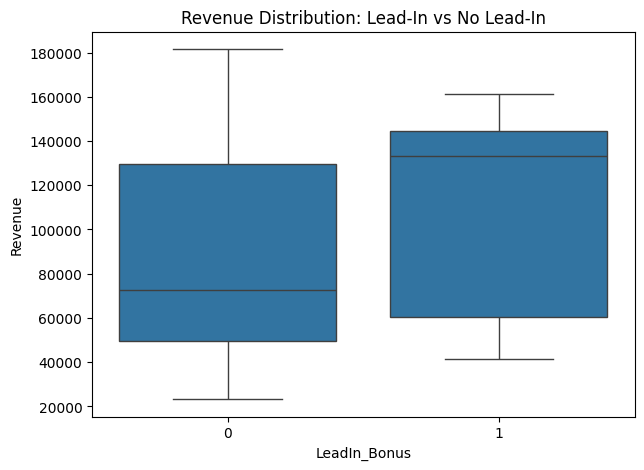

In [463]:
# Lead-in revenue comparison
plt.figure(figsize=(7,5))
sns.boxplot(x="LeadIn_Bonus", y="Revenue", data=df)
plt.title("Revenue Distribution: Lead-In vs No Lead-In")
plt.show()

#Lead-in episodes generate higher median revenue, highlighting the importance of strategic scheduling and audience carryover in improving monetization outcomes.

In [464]:
df.head()

,Show,Season,Air_Date,Week_Number,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
0,Show2,1,2020-10-05,5,0,PreLaunch,8721.066697,10465.280036,3488.426679,44768143,66845.590114,45352.467143,0,0
1,Show4,3,2022-10-15,6,1,Premiere,3524.911498,NaN,8812.278744,38186541,83713.735201,58420.934286,0,0
2,Show2,4,2023-10-27,8,3,Regular,6964.236436,2785.694575,8357.083724,30178358,63736.233023,45484.814286,0,0
3,Show7,1,2024-03-24,11,6,Regular,NaN,7625.926405,6354.938671,27538068,45117.211196,31663.720000,0,0
4,Show5,1,2023-08-14,10,5,Regular,7466.359494,2488.786498,6221.966245,28621044,87525.734172,60840.965714,0,0


#B.Data Cleaning

#Handling Duplicates

In [465]:
df.duplicated().sum()

np.int64(0)

###Duplicate business records were identified after removing the artificial index column and were dropped to ensure accurate weekly aggregation and reliable modeling results.

#Handling Missing Values

#Missing values exist in spend, viewership, and revenue.

In [466]:
df.isnull().sum()

,0
Show,0
Season,0
Air_Date,0
Week_Number,0
Episode_Number,0
Episode_Type,0
Network_TV_Spend,33
Cable_TV_Spend,31
Digital_Spend,34
Impressions,0


<Axes: xlabel='True_Viewership', ylabel='Revenue'>

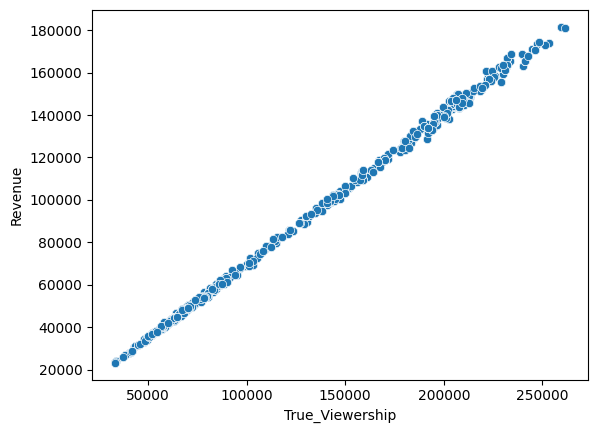

In [467]:
sns.scatterplot(x="True_Viewership", y="Revenue", data=df)
## Viewership and revenue relationship

###Financial performance is closely tied to audience reach, suggesting that maximizing incremental viewership is the most effective lever for revenue growth.

#To handle missing values, we first validated whether marketing activity and performance metrics were recorded at a weekly campaign level and repeated across daily records.

#Campaign Keys

In [468]:
# Defining campaign keys
campaign_keys = ["Show", "Season", "Week_Number"]
# Defining spend columns
cols_to_check = [
    "Network_TV_Spend",
    "Cable_TV_Spend",
    "Digital_Spend",
    "Impressions",
    "True_Viewership",
    "Revenue"
]

grain_check = (
    df.groupby(campaign_keys)[cols_to_check]
      .nunique()
      .reset_index()
)
#grain uniqueness check
# Show problematic rows where ANY metric is not constant within week
grain_issues = grain_check[
    (grain_check[cols_to_check] > 1).any(axis=1)
]

grain_issues

,Show,Season,Week_Number,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue


In [469]:
# Grain uniqueness check
grain_check = df.groupby(campaign_keys)[cols_to_check].nunique()
grain_check.head()
#printing first few rows

Network_TV_Spend  Cable_TV_Spend  Digital_Spend  \
Show  Season Week_Number                                                    
Show1 1      1                           1               1              1   
             2                           1               1              1   
             3                           1               1              1   
             4                           1               1              1   
             5                           1               1              1   

                          Impressions  True_Viewership  Revenue  
Show  Season Week_Number                                         
Show1 1      1                      1                1        1  
             2                      1                1        1  
             3                      1                1        1  
             4                      1                1        1  
             5                      1                1        1

#Checking if there are any weeks where the spend is not same for a specific set of same show,season and week

In [470]:
# identify problematic campaign weeks
problem_weeks = grain_check[(grain_check > 1).any(axis=1)]

problem_weeks

,,,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue
Show,Season,Week_Number,,,,,,


#One Specific Show-Week

In [471]:
# Inspecting specific campaign week for show 1,season 1 for week 3 to check all the values are unique actoss spend,impressions, viewership and revenue
df[
    (df["Show"] == "Show1") &
    (df["Season"] == 1) &
    (df["Week_Number"] == 3)
][["Air_Date"] + cols_to_check]



,Air_Date,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue
605,2020-09-26,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429
781,2020-09-20,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429
1224,2020-09-25,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429
1280,2020-09-23,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429
2118,2020-09-24,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429
2438,2020-09-21,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429
2558,2020-09-22,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429


#Clearly Marketing campaign activity is planned at a weekly level.
#Not only the marketing spends, but also impressions, true viewership, and revenue values remain constant within each Show–Season–Week combination.

#Sorting Data

In [472]:
df = df.sort_values(["Show", "Season", "Week_Number"])
# Sorting campaign chronology

In [473]:
df.head(10)
#Post Sort Check

,Show,Season,Air_Date,Week_Number,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
126,Show1,1,2020-09-08,1,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0
403,Show1,1,2020-09-12,1,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0
511,Show1,1,2020-09-09,1,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,NaN,82590.005714,0,0
537,Show1,1,2020-09-07,1,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0
1870,Show1,1,2020-09-06,1,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0
2476,Show1,1,2020-09-11,1,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0
3114,Show1,1,2020-09-10,1,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0
338,Show1,1,2020-09-17,2,0,PreLaunch,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0
632,Show1,1,2020-09-19,2,0,PreLaunch,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0
930,Show1,1,2020-09-16,2,0,PreLaunch,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0


In [474]:
campaign_keys = ["Show", "Season", "Week_Number"]
#composite keys
cols_to_fill = [
    "Network_TV_Spend",
    "Cable_TV_Spend",
    "Digital_Spend",
    "True_Viewership",
    "Revenue"
]
#selectec columns where null exist
for col in cols_to_fill:
    df[col] = df.groupby(campaign_keys)[col].transform(lambda x: x.ffill().bfill())

#filling function


In [475]:
# Check missing values again
df[cols_to_fill].isnull().sum()

,0
Network_TV_Spend,0
Cable_TV_Spend,0
Digital_Spend,0
True_Viewership,0
Revenue,0


In [476]:
df.isnull().sum()
#overall null check

,0
Show,0
Season,0
Air_Date,0
Week_Number,0
Episode_Number,0
Episode_Type,0
Network_TV_Spend,0
Cable_TV_Spend,0
Digital_Spend,0
Impressions,0


#preparing clean gold data set for further predictive modelling

In [477]:
df.groupby(["Show","Season","Week_Number"])["Revenue"].nunique().value_counts()
#uniqueness check

,count
Revenue,
1,420


In [478]:
# Create Gold-level weekly dataset using the right grain and picking the right performance metrics
gold_df = (
    df.groupby(["Show", "Season", "Week_Number"], as_index=False)
      .agg({
          # Earliest air date represents the start of the campaign week
          "Air_Date": "min",

          # Episode mapping is constant within a campaign week
          "Episode_Number": "first",
          "Episode_Type": "first",

          # Marketing spend values are weekly budgets repeated across daily rows
          # Taking the first observation avoids double counting
          "Network_TV_Spend": "first",
          "Cable_TV_Spend": "first",
          "Digital_Spend": "first",

          # Impressions, viewership, and revenue are also recorded as weekly totals
          # but repeated for each day — therefore we take the first value instead of summing
          "Impressions": "first",
          "True_Viewership": "first",
          "Revenue": "first",

          # Event flags may appear on any day in the week
          # Using max ensures the weekly campaign captures the presence of the event
          "Holiday": "max",
          "LeadIn_Bonus": "max"
      })
)

In [479]:
gold_df.head()

,Show,Season,Week_Number,Air_Date,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
0,Show1,1,1,2020-09-06,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0
1,Show1,1,2,2020-09-13,0,PreLaunch,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0
2,Show1,1,3,2020-09-20,0,PreLaunch,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429,0,0
3,Show1,1,4,2020-09-27,0,PreLaunch,7619.321690,22857.965070,19048.304225,82542651,178971.843013,124396.604286,0,0
4,Show1,1,5,2020-10-04,0,PreLaunch,7133.216268,21399.648804,17833.040670,77276510,192167.775786,131526.194286,0,0


In [480]:
gold_df = gold_df.sort_values(
    ["Show", "Season", "Week_Number"]
).reset_index(drop=True)
# Restore weekly order as group by might do internal ordering

In [481]:
gold_df.head()
#printing first few rows

,Show,Season,Week_Number,Air_Date,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
0,Show1,1,1,2020-09-06,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0
1,Show1,1,2,2020-09-13,0,PreLaunch,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0
2,Show1,1,3,2020-09-20,0,PreLaunch,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429,0,0
3,Show1,1,4,2020-09-27,0,PreLaunch,7619.321690,22857.965070,19048.304225,82542651,178971.843013,124396.604286,0,0
4,Show1,1,5,2020-10-04,0,PreLaunch,7133.216268,21399.648804,17833.040670,77276510,192167.775786,131526.194286,0,0


#Creating a campaign report

In [482]:
campaign_report = gold_df[[
    "Show",
    "Season",
    "Week_Number",
    "Episode_Type",
    "Network_TV_Spend",
    "Cable_TV_Spend",
    "Digital_Spend",
    "Impressions",
    "True_Viewership",
    "Revenue",
    "Holiday",
    "LeadIn_Bonus"
]].copy()

#creating a copy from gold data frame for campaign reporting layer

In [483]:
campaign_report["Total_Spend"] = (
      campaign_report["Network_TV_Spend"]
    + campaign_report["Cable_TV_Spend"]
    + campaign_report["Digital_Spend"]
)
#Total Spend calc in campaign reporting

In [484]:

# CPM
campaign_report["CPM"] = (
    campaign_report["Total_Spend"] / campaign_report["Impressions"] * 1000
).round(2)

# Conversion Rate in %
campaign_report["Conversion_Rate_%"] = (
    campaign_report["True_Viewership"] / campaign_report["Impressions"] * 100
).round(2)

# Revenue per Viewer in cents
campaign_report["Revenue_per_Viewer_cents"] = (
    campaign_report["Revenue"] / campaign_report["True_Viewership"] * 100
).round(2)

# ROAS
campaign_report["ROAS"] = (
    campaign_report["Revenue"] / campaign_report["Total_Spend"]
).round(2)

#Campaign metrics report

In [485]:
campaign_report.head()
#printing first few head rows of campaign_report to check the result

,Show,Season,Week_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus,Total_Spend,CPM,Conversion_Rate_%,Revenue_per_Viewer_cents,ROAS
0,Show1,1,1,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0,26183.935078,0.6,0.27,70.08,3.15
1,Show1,1,2,PreLaunch,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0,31551.995313,0.6,0.25,68.72,2.81
2,Show1,1,3,PreLaunch,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429,0,0,34907.946869,0.6,0.29,71.00,3.49
3,Show1,1,4,PreLaunch,7619.321690,22857.965070,19048.304225,82542651,178971.843013,124396.604286,0,0,49525.590985,0.6,0.22,69.51,2.51
4,Show1,1,5,PreLaunch,7133.216268,21399.648804,17833.040670,77276510,192167.775786,131526.194286,0,0,46365.905742,0.6,0.25,68.44,2.84


#Metrics calculation

#Business Overview

In [486]:
report_summary = {
    "Total Shows": gold_df["Show"].nunique(),
    "Total Episodes": gold_df["Episode_Number"].nunique(),
    "Total Campaign Weeks": len(gold_df),
#total episodes,shows,and campaign weeks

    # Recompute Total Spend directly
    "Total Spend": (
        gold_df["Network_TV_Spend"]
        + gold_df["Cable_TV_Spend"]
        + gold_df["Digital_Spend"]
    ).sum(),

    "Total Revenue": gold_df["Revenue"].sum(),
    "Total Viewership": gold_df["True_Viewership"].sum()
}
#total revenue and viewership activity
summary_df = pd.DataFrame(
    report_summary.items(),
    columns=["High level Metrics", "Value"]
)

summary_df["Value"] = summary_df["Value"].apply(
    lambda x: f"{x:,.0f}" if isinstance(x, (int, float)) else x
)

summary_df

,High level Metrics,Value
0,Total Shows,8
1,Total Episodes,11
2,Total Campaign Weeks,420
3,Total Spend,"14,018,909"
4,Total Revenue,"37,402,211"
5,Total Viewership,"53,356,378"


#The dataset covers 8 shows across 420 campaign weeks, representing a total marketing investment of approximately $14.0M. This investment supported the generation of about $37.4M in revenue and over 53M total viewers, highlighting the large scale of audience reach driven by media activity. The results indicate that even moderate changes in marketing allocation and campaign timing can meaningfully influence audience growth and financial performance.

#Creating Total_Spend in Gold Dataset

In [487]:
gold_df["Total_Spend"] = (
    gold_df["Network_TV_Spend"]
    + gold_df["Cable_TV_Spend"]
    + gold_df["Digital_Spend"]
)
#creating total spend in gold_Df

#Lifecycle Performance Summary

In [488]:
# Episode type performance
gold_df.groupby("Episode_Type")[[
    "Total_Spend",
    "Impressions",
    "True_Viewership",
    "Revenue",
]].mean()

#grouping by episode type

,Total_Spend,Impressions,True_Viewership,Revenue
Episode_Type,,,,
Finale,38063.764273,6.633773e+07,143737.057139,101093.790459
PreLaunch,33952.819183,5.949593e+07,105450.874343,73919.828031
Premiere,35040.077581,6.182531e+07,130828.734554,91794.524847
Regular,32225.923778,5.678299e+07,137970.595470,96663.225108


###Finale and Premiere episodes attract higher average marketing investment and deliver stronger audience reach and revenue compared to Regular and Pre-Launch periods. This indicates that media strategies are intentionally concentrated around key lifecycle moments to maximize audience engagement and monetization. The comparatively lower performance during Pre-Launch phases suggests that early promotional efforts are focused more on awareness building than immediate revenue generation.

In [489]:
campaign_report.head()

,Show,Season,Week_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus,Total_Spend,CPM,Conversion_Rate_%,Revenue_per_Viewer_cents,ROAS
0,Show1,1,1,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0,26183.935078,0.6,0.27,70.08,3.15
1,Show1,1,2,PreLaunch,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0,31551.995313,0.6,0.25,68.72,2.81
2,Show1,1,3,PreLaunch,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429,0,0,34907.946869,0.6,0.29,71.00,3.49
3,Show1,1,4,PreLaunch,7619.321690,22857.965070,19048.304225,82542651,178971.843013,124396.604286,0,0,49525.590985,0.6,0.22,69.51,2.51
4,Show1,1,5,PreLaunch,7133.216268,21399.648804,17833.040670,77276510,192167.775786,131526.194286,0,0,46365.905742,0.6,0.25,68.44,2.84


##Top Campaign Analysis

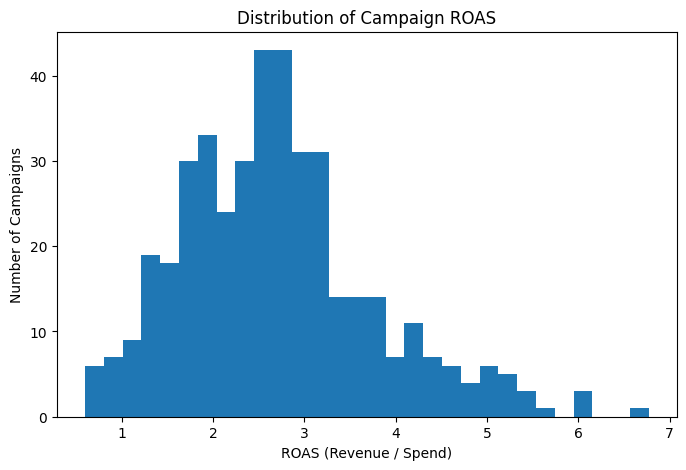

In [490]:
plt.figure(figsize=(8,5))

plt.hist(campaign_report["ROAS"], bins=30)

plt.title("Distribution of Campaign ROAS")
plt.xlabel("ROAS (Revenue / Spend)")
plt.ylabel("Number of Campaigns")

plt.show()

#ROAS varies across campaigns, with most delivering moderate returns while a subset achieves significantly higher efficiency.

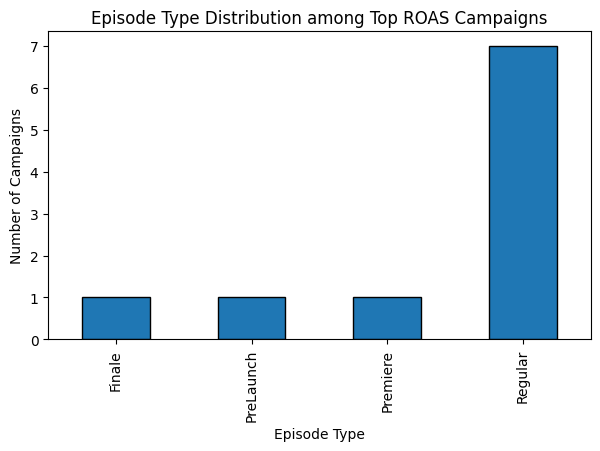

In [491]:
# Select top ROAS campaigns
top_roas = campaign_report.sort_values("ROAS", ascending=False).head(10)

# Plot episode type distribution
plt.figure(figsize=(7,4))

top_roas.groupby("Episode_Type")["ROAS"].count().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Episode Type Distribution among Top ROAS Campaigns")
plt.xlabel("Episode Type")
plt.ylabel("Number of Campaigns")

plt.show()

#Top-ROAS campaigns are largely concentrated in Regular episodes, indicating that steady programming periods may deliver more efficient marketing returns than high-spend marquee episodes.

#Top Spend by Episode type

In [492]:
# Select top spend campaigns
top_spend = campaign_report.sort_values("Total_Spend", ascending=False).head(10)

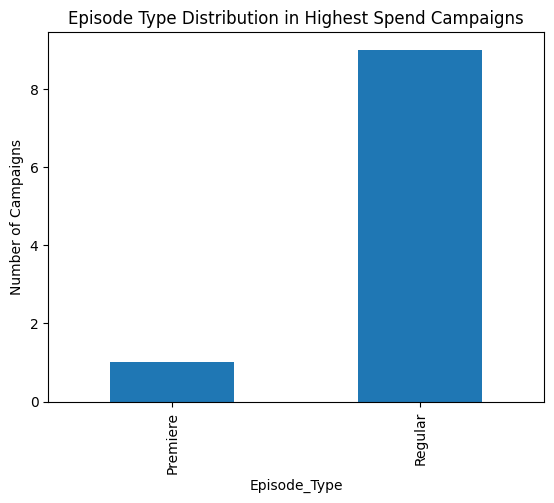

In [493]:
# Episode type spend distribution
top_spend.groupby("Episode_Type")["Total_Spend"].count().plot(kind="bar")

# Add chart title
plt.title("Episode Type Distribution in Highest Spend Campaigns")

# Add axis label
plt.ylabel("Number of Campaigns")

# Render chart
plt.show()

#High-spend campaigns are predominantly concentrated in Regular episodes, indicating that a significant portion of the marketing budget is consistently deployed to sustain ongoing audience engagement rather than only key lifecycle events.

#Highest Reach Ads by Episode Type

In [494]:
# Selecting top reach campaign by episode type
top_reach = campaign_report.sort_values("Impressions", ascending=False).head(10)

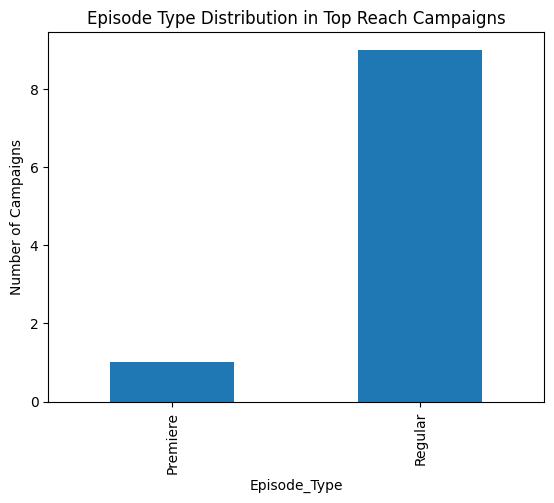

In [495]:
# Episode type Impression distribution
top_reach.groupby("Episode_Type")["Impressions"].count().plot(kind="bar")

# Add chart title
plt.title("Episode Type Distribution in Top Reach Campaigns")

# Add axis label
plt.ylabel("Number of Campaigns")

# Render chart
plt.show()

#Top audience-reach campaigns are predominantly concentrated in Regular episodes, indicating that consistent programming periods play a key role in delivering large-scale viewer exposure.

#Highest Viewership Episode Types

In [496]:
top_view = campaign_report.sort_values("True_Viewership", ascending=False).head(10)
# Select top viewership campaigns

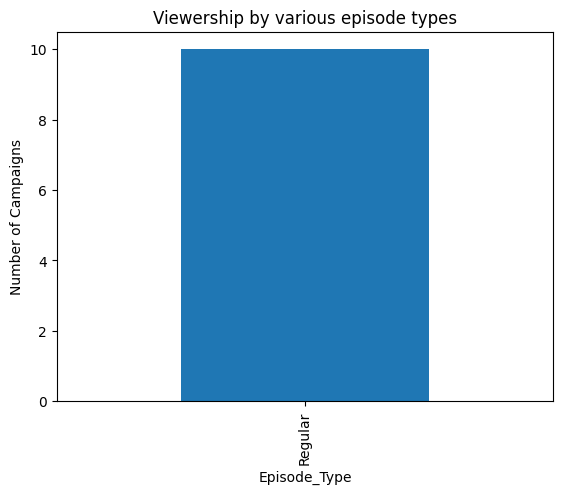

In [497]:
# Episode type viewership distribution
top_view.groupby("Episode_Type")["True_Viewership"].count().plot(kind="bar")

# Add chart title
plt.title("Viewership by various episode types")

# Add axis label
plt.ylabel("Number of Campaigns")

# Render chart
plt.show()

#All top-performing viewership campaigns are concentrated in Regular episodes

#Funnel Efficiency: Viewer conversion rate from impressions by episode type.

In [498]:
# Aggregate episode metrics
episode_conv = (
    campaign_report
    .groupby("Episode_Type")
    .agg({
        "True_Viewership": "sum",  # Total viewership
        "Impressions": "sum"       # Total impressions
    })
)

# Computing conversion rate
episode_conv["Conversion"] = (
    episode_conv["True_Viewership"] /
    episode_conv["Impressions"]
)

# Rank by conversion
episode_conv = episode_conv.sort_values("Conversion", ascending=False)
episode_conv

,True_Viewership,Impressions,Conversion
Episode_Type,,,
Regular,3.090541e+07,12719389838,0.002430
Finale,4.024638e+06,1857456386,0.002167
Premiere,3.663205e+06,1731108774,0.002116
PreLaunch,1.476312e+07,8329430703,0.001772


#Regular episodes may exhibit higher conversion efficiency from impressions to viewers, while lifecycle peaks such as Premiere and Finale might be more focused on reach expansion rather than conversion optimization.

#Funnel Efficiency Trend Over Weeks by show

In [499]:
# Aggregate weekly show metrics
show_week_metrics = (
    campaign_report
    .groupby(["Show", "Week_Number"])
    .agg({
        "True_Viewership": "sum", # Weekly viewership
        "Impressions": "sum",     # Weekly impressions
        "Total_Spend": "sum"      # Weekly total spend
    })
    .reset_index()
)


# Computing weekly conversion
show_week_metrics["Conversion"] = (
    show_week_metrics["True_Viewership"] /
    show_week_metrics["Impressions"]
)

#Time Series Funnel Efficiency of every show across weeks

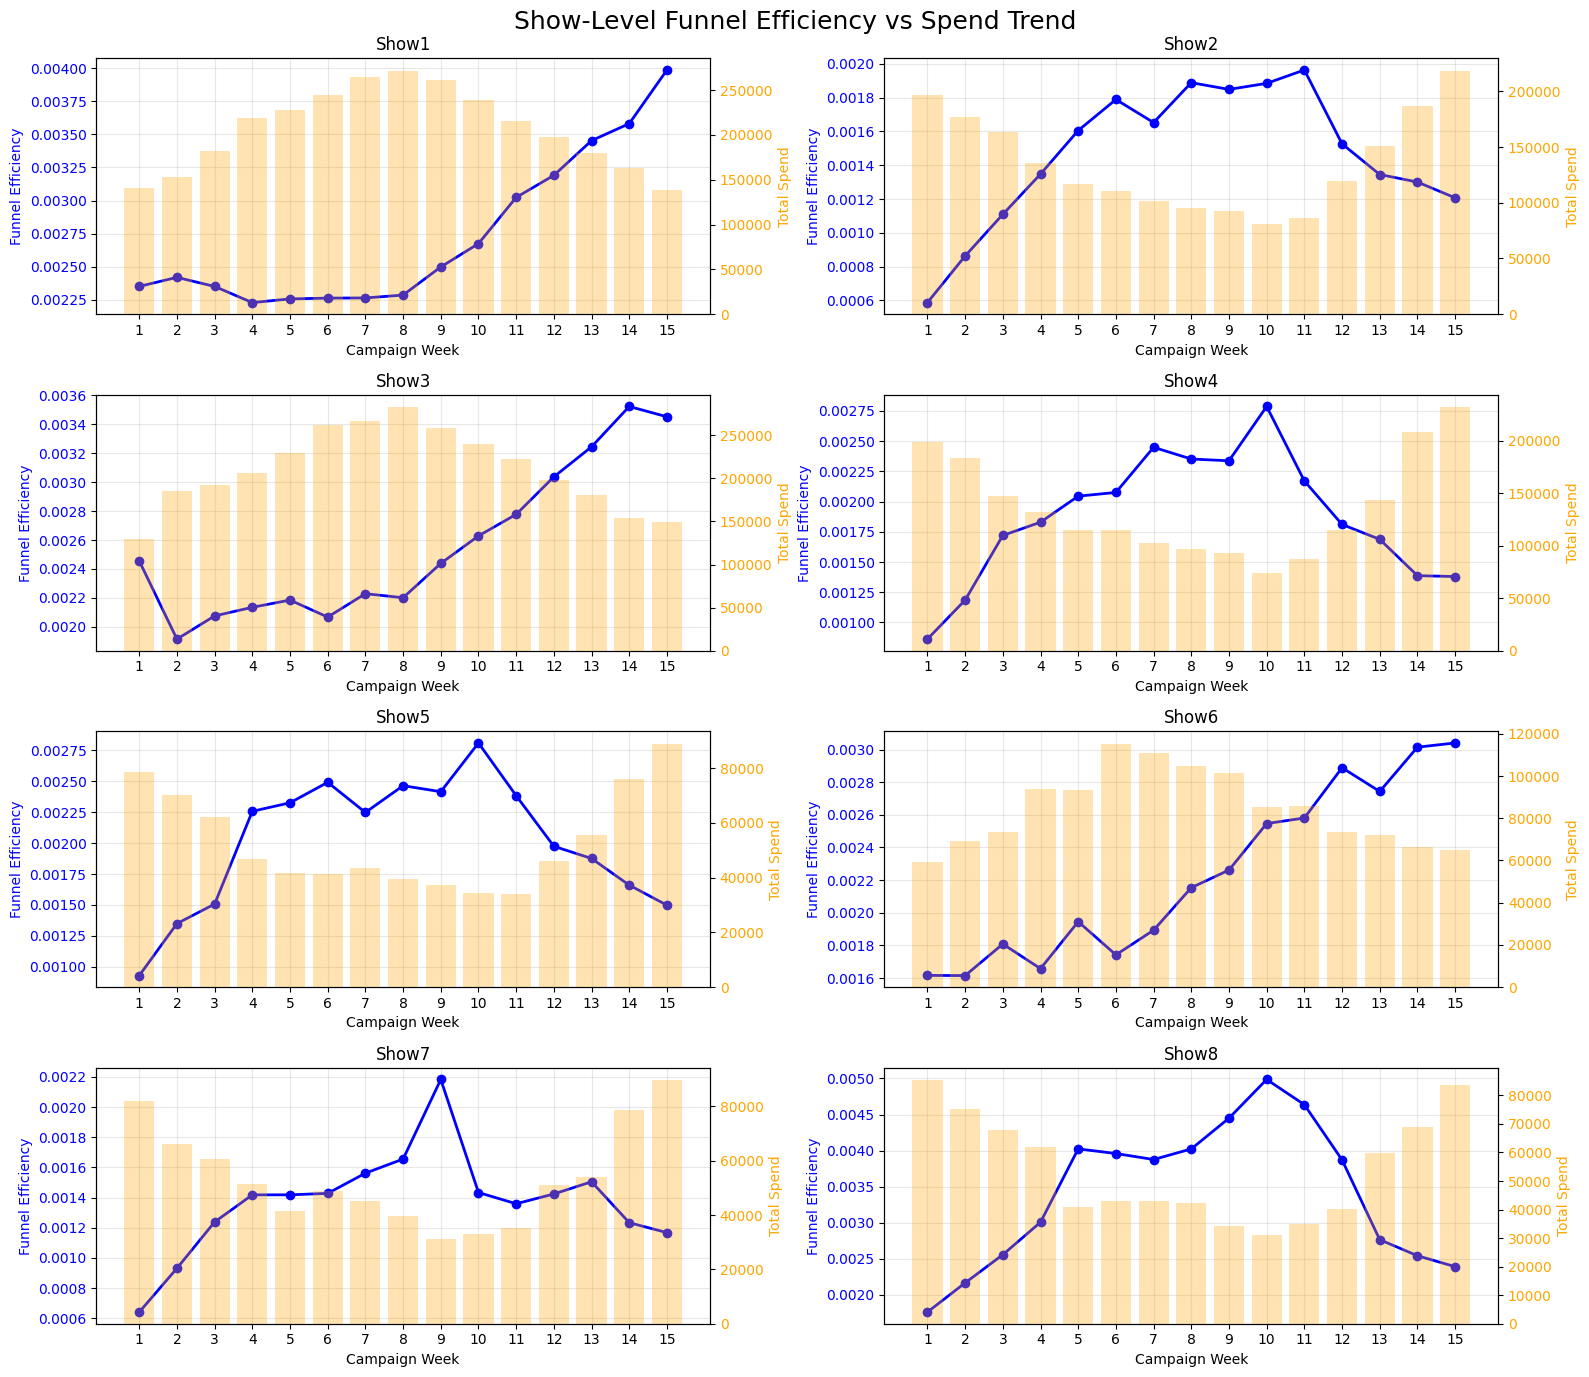

In [500]:
# Get unique shows
shows = sorted(show_week_metrics["Show"].unique())

# Create subplot grid
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=False)
axes = axes.flatten()

# Loop through shows
for i, show in enumerate(shows):

# Filter show data
    subset = (
        show_week_metrics[show_week_metrics["Show"] == show]
        .sort_values("Week_Number")
    )

 # Select subplot
    ax1 = axes[i]

    # Funnel Efficiency
    ax1.plot(
        subset["Week_Number"],
        subset["Conversion"],
        marker="o",
        color="blue",
        linewidth=2,
        label="Funnel Efficiency"
    )
    ax1.set_ylabel("Funnel Efficiency", color="blue")
    ax1.tick_params(axis='y', labelcolor="blue")
    ax1.set_xticks(subset["Week_Number"])
    ax1.set_xlabel("Campaign Week")
    ax1.set_title(show)
    ax1.grid(alpha=0.3)

    # Spend (Secondary Axis)
    ax2 = ax1.twinx()
    ax2.bar(
        subset["Week_Number"],
        subset["Total_Spend"],
        alpha=0.3,
        color="orange",
        label="Spend"
    )
    # Secondary axis label
    ax2.set_ylabel("Total Spend", color="orange")
    # Style second axis
    ax2.tick_params(axis='y', labelcolor="orange")

plt.suptitle("Show-Level Funnel Efficiency vs Spend Trend", fontsize=18)
plt.tight_layout()
plt.show()

#For Show 1, Show 3, and Show 6

#Shows 1, 3, and 6 may exhibit improving funnel efficiency in later campaign weeks despite earlier higher spend, suggesting that sustained marketing exposure might gradually enhance audience engagement and conversion.

#For Show 2, Show 4, and Show 5

#Shows 2, 4, and 5 may display fluctuating or declining funnel efficiency despite variations in spend, indicating that higher marketing investment does not always translate into proportional gains in audience conversion.

#Scatter Plot (All Shows Combined)

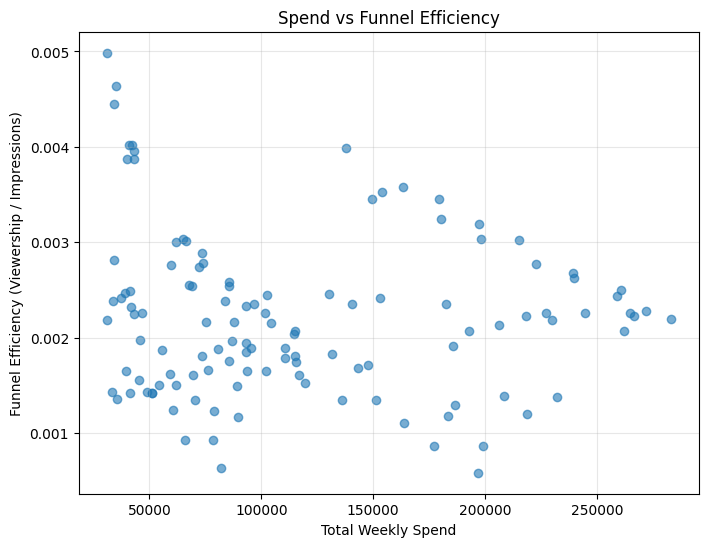

In [501]:
# Spend efficiency scatter
plt.figure(figsize=(8,6))

# Plot spend vs conversion
plt.scatter(
    show_week_metrics["Total_Spend"],
    show_week_metrics["Conversion"],
    alpha=0.6
)

plt.xlabel("Total Weekly Spend")
plt.ylabel("Funnel Efficiency (Viewership / Impressions)")
plt.title("Spend vs Funnel Efficiency")
plt.grid(alpha=0.3)

plt.show()

#Higher spend may not consistently improve conversion efficiency, indicating possible diminishing returns at elevated investment levels.

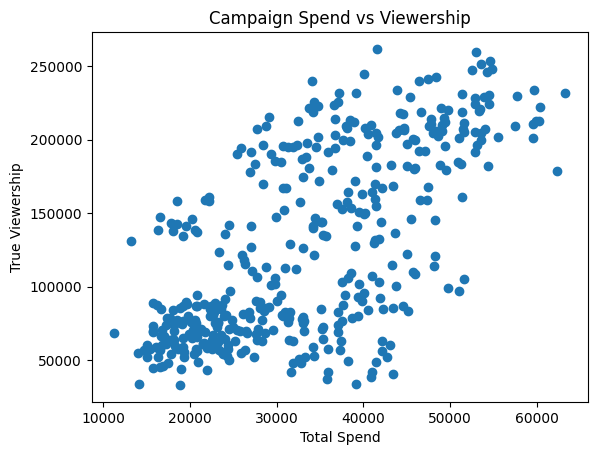

In [502]:
# Spend viewership scatter
plt.scatter(campaign_report["Total_Spend"], campaign_report["True_Viewership"])
plt.xlabel("Total Spend")
plt.ylabel("True Viewership")
plt.title("Campaign Spend vs Viewership")
plt.show()

#

#Higher spend is generally linked with higher viewership, though campaign performance varies significantly, indicating differences in marketing effectiveness.
#there might be Heterogeneity across shows ,episode types, timing and channel mix

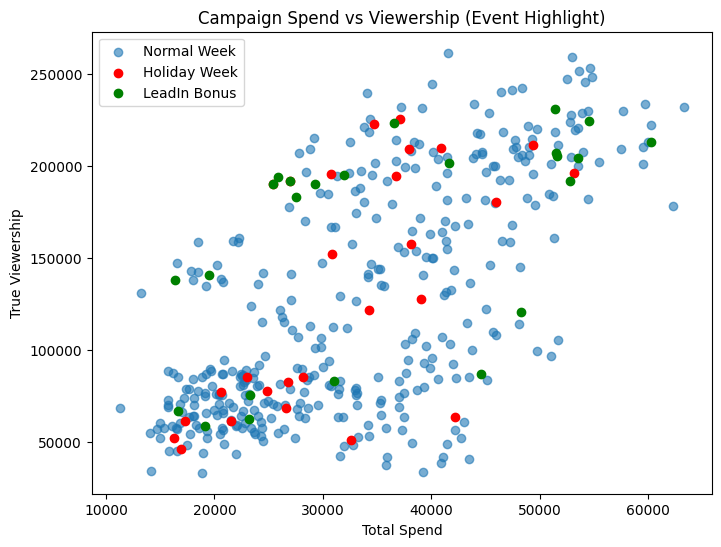

In [503]:
# Event highlight scatter
plt.figure(figsize=(8,6))

# Normal weeks
plt.scatter(
    campaign_report[
        (campaign_report["Holiday"] == 0) &
        (campaign_report["LeadIn_Bonus"] == 0)
    ]["Total_Spend"],
    gold_df[
        (campaign_report["Holiday"] == 0) &
        (campaign_report["LeadIn_Bonus"] == 0)
    ]["True_Viewership"],
    label="Normal Week",
    alpha=0.6
)

# Holiday weeks
plt.scatter(
    gold_df[campaign_report["Holiday"] == 1]["Total_Spend"],
    gold_df[campaign_report["Holiday"] == 1]["True_Viewership"],
    color="red",
    label="Holiday Week"
)

# Lead-in bonus weeks
plt.scatter(
    gold_df[campaign_report["LeadIn_Bonus"] == 1]["Total_Spend"],
    gold_df[campaign_report["LeadIn_Bonus"] == 1]["True_Viewership"],
    color="green",
    label="LeadIn Bonus"
)

plt.xlabel("Total Spend")
plt.ylabel("True Viewership")
plt.title("Campaign Spend vs Viewership (Event Highlight)")
plt.legend()
plt.show()

#Seasonal timing alone may not guarantee higher viewership, while strategic scheduling with strong lead-in programs might enhance audience reach at comparable spend levels.

#Question 1:

#Briefly explain the purpose and main challenges of each medallion layer in 2-3 sentences


###Bronze layer:
###Raw source data is ingested and stored with minimal transformation to preserve original records and enable traceability. In this case study, the Bronze ingestion step is assumed to have occurred upstream and is not directly provided.

###Silver layer:
###The provided dataset represents the Silver layer, where campaign data exists at a structured but not fully business-ready level. Additional cleaning steps such as handling duplicates, missing values, and chronological ordering were performed to improve data quality.

###Gold layer:
###The cleaned Silver data was transformed into a Gold-level dataset by aggregating campaign activity into weekly metrics at the correct business grain, enabling reliable KPI reporting and marketing mix modeling

#Question 2 : Given a sudden schema change upstream, describe your process for ensuring the downstream silver and gold layers still function without interruption

#What would I do? (Analytical)

###In the event of an upstream change, I would pause downstream processing to avoid incorrect aggregations and continue reporting using the last validated Gold dataset. I would then assess whether the issue is a schema change (structural changes requiring ETL updates), a grain change (level-of-detail changes requiring revised aggregation and adstock sequencing), or a metric definition change (business meaning changes requiring metric validation and potential MMM retraining). Once transformations and model inputs are validated, the corrected data would be promoted back to the Silver and Gold layers.


###For example, If the pipeline is running on AWS, I would implement schema validation at ingestion and route any failed data to a quarantine location in S3 while triggering alerts through CloudWatch or SNS. I would then apply a controlled fix by versioning the schema, updating Glue or SageMaker transformation logic, adjusting aggregation queries, and running validation checks. Once the pipeline produces accurate weekly aggregations and business metrics, the corrected data would be safely promoted to the Silver and Gold layers.

#Question 3: Describe how you would implement data lineage and monitoring across layers to quickly identify and resolve data quality issues

###I would implement data lineage to clearly track how data flows from Raw to Silver to Gold and how each business metric is derived. In parallel, I would introduce monitoring checks for schema drift, missing values, duplicates, unexpected row count changes, incorrect business grain, and abnormal metric values. This would allow issues to be quickly traced to the affected layer and resolved before impacting downstream reporting or modeling.

In [504]:
gold_df.head()
#printing first few rows

,Show,Season,Week_Number,Air_Date,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus,Total_Spend
0,Show1,1,1,2020-09-06,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0,26183.935078
1,Show1,1,2,2020-09-13,0,PreLaunch,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0,31551.995313
2,Show1,1,3,2020-09-20,0,PreLaunch,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429,0,0,34907.946869
3,Show1,1,4,2020-09-27,0,PreLaunch,7619.321690,22857.965070,19048.304225,82542651,178971.843013,124396.604286,0,0,49525.590985
4,Show1,1,5,2020-10-04,0,PreLaunch,7133.216268,21399.648804,17833.040670,77276510,192167.775786,131526.194286,0,0,46365.905742


#Dropping Total spend form gold_df

In [505]:
cols_to_drop = [
    "Total_Spend",

]

gold_model_df = gold_df.drop(columns=cols_to_drop)
#Dropping Business metrics we calculated earlier

In [506]:
gold_model_df.head()
#printing first few rows

,Show,Season,Week_Number,Air_Date,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
0,Show1,1,1,2020-09-06,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0
1,Show1,1,2,2020-09-13,0,PreLaunch,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0
2,Show1,1,3,2020-09-20,0,PreLaunch,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429,0,0
3,Show1,1,4,2020-09-27,0,PreLaunch,7619.321690,22857.965070,19048.304225,82542651,178971.843013,124396.604286,0,0
4,Show1,1,5,2020-10-04,0,PreLaunch,7133.216268,21399.648804,17833.040670,77276510,192167.775786,131526.194286,0,0


In [507]:
gold_model_df.info()
#Gold Data Set data type Check

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Show              420 non-null    object        
 1   Season            420 non-null    int64         
 2   Week_Number       420 non-null    int64         
 3   Air_Date          420 non-null    datetime64[ns]
 4   Episode_Number    420 non-null    int64         
 5   Episode_Type      420 non-null    object        
 6   Network_TV_Spend  420 non-null    float64       
 7   Cable_TV_Spend    420 non-null    float64       
 8   Digital_Spend     420 non-null    float64       
 9   Impressions       420 non-null    int64         
 10  True_Viewership   420 non-null    float64       
 11  Revenue           420 non-null    float64       
 12  Holiday           420 non-null    int64         
 13  LeadIn_Bonus      420 non-null    int64         
dtypes: datetime64[ns](1), floa

In [508]:
gold_model_df.to_csv("gold_model_dataset.csv", index=False)
# Save without index

In [509]:
from google.colab import files
files.download("gold_model_dataset.csv")
#Download as csv

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#C.Modeling

#Fit a marketing mix model using multiple linear regression, or Bayesian statistics, to estimate the effects of each spend channel

#Creating Dummy Varaibles for the Episode Type

In [510]:
gold_model_df["Episode_Type"] = pd.Categorical(
    gold_model_df["Episode_Type"],
    categories=["Regular", "Premiere", "Finale", "PreLaunch"],
    ordered=False
)

#creating dummy variables for episode type

#converting episode type to dummies

In [511]:
gold_model_df = pd.get_dummies(
    gold_model_df,
    columns=["Episode_Type"],
    drop_first=True,
    dtype=int
)

#dropping one episode type i.e., to avoid dummy trap that leads to multicollinearity

#The Episode_Type variable was converted into dummy variables to capture lifecycle effects such as premiere launches, finale peaks, or pre-launch marketing periods. One category was dropped to avoid multicollinearity and serve as the baseline for comparison. This baseline does not represent “normal business conditions,” since contextual factors like holidays or lead-in bonuses can still influence performance. Instead, the coefficients measure the incremental lifecycle impact of each episode type while controlling for other drivers such as marketing spend and event effects.

#restoring order back again after creating dummy variable

In [512]:
gold_model_df = gold_model_df.sort_values(
    ["Show", "Season", "Week_Number"]
).reset_index(drop=True)
#grain sort after creating dummies

In [513]:
gold_model_df.head()
#Printing first few rows after creating dummies

,Show,Season,Week_Number,Air_Date,Episode_Number,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus,Episode_Type_Premiere,Episode_Type_Finale,Episode_Type_PreLaunch
0,Show1,1,1,2020-09-06,0,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0,0,0,1
1,Show1,1,2,2020-09-13,0,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0,0,0,1
2,Show1,1,3,2020-09-20,0,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429,0,0,0,0,1
3,Show1,1,4,2020-09-27,0,7619.321690,22857.965070,19048.304225,82542651,178971.843013,124396.604286,0,0,0,0,1
4,Show1,1,5,2020-10-04,0,7133.216268,21399.648804,17833.040670,77276510,192167.775786,131526.194286,0,0,0,0,1


#Taking True_ViewerShip as a Target Variable

In [514]:
y = gold_model_df["True_Viewership"]
#Target Variable

#In this analysis, True Viewership is used as the target variable because revenue is largely a direct function of the number of viewers. Since revenue per viewer remains relatively stable across shows, overall revenue can be estimated later using a global average revenue-per-viewer rate or, if needed, a more granular show-specific conversion rate.

#We also excluded Impressions from the features because they are largely generated by marketing spend, making them highly correlated with spend variables and likely to cause multicollinearity while also diluting the true impact of spend on viewership.

In [515]:
X = gold_model_df[
    [
        "Network_TV_Spend",
        "Cable_TV_Spend",
        "Digital_Spend",
        "Holiday",
        "LeadIn_Bonus",
        "Week_Number",
        "Episode_Type_PreLaunch",
        "Episode_Type_Premiere",
        "Episode_Type_Finale"
    ]
]

# Independent Variables

#Initial OLS for explanatory power

In [516]:
import statsmodels.api as sm
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())
#ols regression for inference

                            OLS Regression Results                            
Dep. Variable:        True_Viewership   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.561
Method:                 Least Squares   F-statistic:                     60.57
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           7.94e-70
Time:                        23:34:06   Log-Likelihood:                -5059.4
No. Observations:                 420   AIC:                         1.014e+04
Df Residuals:                     410   BIC:                         1.018e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -1.06

#The OLS model explains about 57% of the variation in true viewership (R² = 0.57), indicating reasonable explanatory power given that important external factors such as genre, competition, and audience demographics are not included and are assumed to be reflected in baseline show performance.

#Marketing spend variables show strong positive and statistically significant effects. Network TV and Cable TV spend emerge as the primary drivers of audience reach, while Digital spend also has a significant but relatively smaller marginal impact.

#Contextual event variables show mixed influence. The Holiday effect is not statistically significant, suggesting that seasonal timing alone may not guarantee higher viewership. The Lead-in bonus shows a marginal positive effect (p ≈ 0.07), indicating potential audience carryover from high-viewership programs.

#Among lifecycle variables, Finale episodes show a statistically significant negative deviation from the baseline episode type after controlling for marketing spend and events, while Premiere and Pre-Launch episodes are not significantly different.

#The high condition number suggests potential multicollinearity among media spend variables, which is common in Marketing Mix Modeling due to coordinated channel investments. While the baseline linear model provides useful directional and inferential insights, it does not fully capture carryover effects and diminishing returns in marketing response, which are later addressed using adstock and saturation transformations.

#Linear regression provides useful inferential and directional insights into how marketing spend influences viewership, although assumptions such as linear response and potential multicollinearity across media channels may limit its ability to fully capture real marketing dynamics. Important unobserved factors like genre, competition, and audience preferences are assumed to be reflected in baseline show performance. Model accuracy and realism can be further improved by incorporating non-linear transformations such as adstock and saturation to capture carryover effects and diminishing marginal returns in marketing impact.

#There are differences across episode types because EDA shows raw trends, whereas OLS shows adjusted effects after accounting for other variables.

#Check for Multicollinearity


In [517]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Create VIF dataframe
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

                  Feature        VIF
0                   const  42.766381
1        Network_TV_Spend   1.065523
2          Cable_TV_Spend   1.020715
3           Digital_Spend   1.067740
4                 Holiday   1.010567
5            LeadIn_Bonus   1.069651
6             Week_Number   5.427063
7  Episode_Type_PreLaunch   4.721940
8   Episode_Type_Premiere   1.425408
9     Episode_Type_Finale   1.471266


#VIF results indicate no severe multicollinearity among marketing spend variables, as all channel VIFs are close to 1. However, variables such as Week_Number and certain episode-type indicators show moderate multicollinearity, which is expected given their relationship with time trends and lifecycle patterns.

#Week_Number was evaluated during multicollinearity diagnostics because it captures temporal campaign progression and potential decay patterns. However, it was intentionally excluded from the baseline vanilla regression to maintain a simple and interpretable starting model. It can be incorporated in the final or extended model specification to better capture time-driven variation in viewership.

#Building Baseline Vanilla Linear Regression MMM without standard scaling,basic split and no adstock and/or saturation
#Although Week_Number exhibits moderate multicollinearity and captures temporal lifecycle effects such as awareness build-up and audience fatigue, it was not included in the baseline vanilla regression model.

In [518]:
# Convert to datetime
gold_model_df["Air_Date"] = pd.to_datetime(gold_model_df["Air_Date"])

# Sort chronologically
gold_model_df = gold_model_df.sort_values(
    ["Show", "Season", "Air_Date"]
).reset_index(drop=True)

#Define Features

In [519]:
features = [
    "Network_TV_Spend",
    "Cable_TV_Spend",
    "Digital_Spend",
    "Holiday",
    "LeadIn_Bonus",
    "Episode_Type_PreLaunch",
    "Episode_Type_Premiere",
    "Episode_Type_Finale"
]
#features list
X = gold_model_df[features]
y = gold_model_df["True_Viewership"]

#defining features and target label

#Train Test Split

In [520]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
#importing necessary libraries

# Select model features
features = [
    "Network_TV_Spend",
    "Cable_TV_Spend",
    "Digital_Spend",
    "Holiday",
    "LeadIn_Bonus",
    "Episode_Type_PreLaunch",
    "Episode_Type_Premiere",
    "Episode_Type_Finale"
]

# Define predictors and target
X = gold_model_df[features]
y = gold_model_df["True_Viewership"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)
#split

model = LinearRegression()
#model
model.fit(X_train, y_train)
#fitting
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

#predictions

In [521]:
# Evaluate model performance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Create train vs test metrics table
metrics_df = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Train": [
        r2_score(y_train, y_pred_train),
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        mean_absolute_error(y_train, y_pred_train)
    ],
    "Test": [
        r2_score(y_test, y_pred_test),
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        mean_absolute_error(y_test, y_pred_test)
    ]
})

# Display metrics
metrics_df

,Metric,Train,Test
0,R2,0.599170,0.341755
1,RMSE,40667.132549,46636.639372
2,MAE,32903.316367,39345.710366


In [522]:
intercept = model.intercept_
coefficients = model.coef_

for f, c in zip(features, coefficients):
    print(f"{f}: {c}")

print("Intercept:", intercept)

Network_TV_Spend: 4.253486181038854
Cable_TV_Spend: 4.82556356953525
Digital_Spend: 2.43175986470777
Holiday: 11865.164361517247
LeadIn_Bonus: 16045.412415136123
Episode_Type_PreLaunch: -36858.44633819897
Episode_Type_Premiere: -19995.417530173036
Episode_Type_Finale: -14928.134735616948
Intercept: 12272.026036892625


#Model Setup

#Marketing spend variables (Network TV, Cable TV, and Digital) are modeled in original dollar units, allowing coefficients to be interpreted directly in business terms as the expected change in viewership for a one-dollar increase in spend. Contextual variables such as Holiday, Lead-in Bonus, and Episode Type dummies capture shifts in baseline audience demand relative to regular episodes. This helps isolate the marginal contribution of marketing investment from scheduling and lifecycle effects.

#Baseline Regression Performance
#The baseline model shows moderate predictive performance, with an R² of about 0.60 on training data and 0.34 on test data, indicating noticeable generalization loss — a common outcome in noisy marketing datasets. This suggests that while the model captures directional relationships between spend and viewership, its forecasting stability is limited. Since the split was not strictly time-based, training and test samples may share similar campaign patterns. A time-series split could provide a more realistic evaluation. Further improvements using adstock and saturation transformations are expected to better capture marketing response dynamics.

#Channel Impact
#Network TV Spend (~4.25)
###$1 increase in Network TV spend is associated with roughly 4 additional viewers, indicating a positive contribution to audience reach.

#Cable TV Spend (~4.83)
###Cable TV shows the strongest directional effect, with each additional $1 in spend linked to about 5 incremental viewers.

#Digital Spend (~2.43)
###Digital marketing also contributes positively but with a smaller marginal effect, suggesting a supportive rather than primary reach role.

#Contextual Effects
#Holiday (~+11.9K viewers)
###Episodes aired during holiday weeks tend to attract higher baseline viewership, reflecting favorable seasonal demand.
#Lead-in Bonus (~+16K viewers)
###Episodes following high-viewership programs show additional audience carryover, improving reach even without proportional increases in spend.

#Lifecycle Effects (Relative to Regular Episodes)

#Pre-Launch (~−36.9K viewers)
###Lower viewership reflects awareness-building campaigns before full audience engagement.

#Premiere (~−20K viewers)
###Premiere episodes show slightly lower viewership after controlling for marketing investment and context.

#Finale (~−14.9K viewers)
###Finale episodes also exhibit a small negative deviation from regular episodes, suggesting that higher promotional intensity does not always translate into proportionally higher audience response

###The regression intercept represents the theoretical baseline viewership when marketing spend and contextual variables are set to zero. However, in this case study, true baseline demand varies across shows and seasons, since unobserved factors such as genre appeal, competition, and audience demographics are assumed to be embedded within each show’s inherent performance. Therefore, the intercept should be interpreted as a statistical reference point rather than the actual organic audience level for all episodes.

###Using the model’s directional coefficients, incremental budget estimates can still be used to assess how much additional marketing investment may be required to achieve a target viewership level (e.g., 300K viewers), but such estimates should be interpreted as approximate and channel-relative rather than absolute predictions.

In [523]:
# Baseline viewership for a regular episode
baseline_viewers = 12272.026036892625

# Target viewership
target_viewers = 300000

# Incremental viewers needed
incremental_viewers_needed = target_viewers - baseline_viewers

# Channel coefficients (viewers gained per $1 spent)
network_coef = 4.253
cable_coef = 4.826
digital_coef = 2.432

# Budget needed if only one channel is used
network_budget = incremental_viewers_needed / network_coef
cable_budget = incremental_viewers_needed / cable_coef
digital_budget = incremental_viewers_needed / digital_coef

print("Baseline viewers for a regular episode:", round(baseline_viewers))
print("Target viewers:", target_viewers)
print("Incremental viewers needed:", round(incremental_viewers_needed))
print()

print("Estimated budget needed by channel:")
print(f"Network TV only: ${network_budget:,.2f}")
print(f"Cable TV only:   ${cable_budget:,.2f}")
print(f"Digital only:    ${digital_budget:,.2f}")

Baseline viewers for a regular episode: 12272
Target viewers: 300000
Incremental viewers needed: 287728

Estimated budget needed by channel:
Network TV only: $67,652.94
Cable TV only:   $59,620.38
Digital only:    $118,309.20


#In future iterations, alternate episode types can be used as the reference dummy category to better understand how baseline viewership shifts across different programming contexts and improve interpretation of marketing impact.

#Lets move on to Adstock function

In [524]:
# Geometric adstock transformation
def geometric_adstock(series, theta):
    """
    Apply geometric adstock transformation.

    Adstock_t = Spend_t + theta * Adstock_(t-1)

    theta = carryover rate
    Higher theta → longer advertising memory
    Lower theta → faster decay of impact
    """

    # Initialize adstock array
    adstock = np.zeros(len(series))
    spend = series.values

    # First period adstock equals spend
    adstock[0] = spend[0]

    # Recursive carryover calculation
    for t in range(1, len(spend)):
        adstock[t] = spend[t] + theta * adstock[t - 1]

    return adstock
    # Return transformed series

#Conditional Adstock Assignment based on the spend channel

In [525]:
# Set channel decay rates
theta_network = 0.6
theta_cable = 0.6
theta_digital = 0.4


# Apply adstock transformation
gold_model_df["Network_TV_Adstock"] = geometric_adstock(
    gold_model_df["Network_TV_Spend"], theta_network
)

gold_model_df["Cable_TV_Adstock"] = geometric_adstock(
    gold_model_df["Cable_TV_Spend"], theta_cable
)

gold_model_df["Digital_Adstock"] = geometric_adstock(
    gold_model_df["Digital_Spend"], theta_digital
)

#Ad Decay Assumptions:
#Network TV: 60% of last week’s impact continues
#Cable TV: 60% carryover
#Digital: Only 40% carryover → faster decay

#Building feature set with adstocked channels

In [526]:
features = [
    "Network_TV_Adstock",
    "Cable_TV_Adstock",
    "Digital_Adstock",
    "Holiday",
    "LeadIn_Bonus",
    "Episode_Type_PreLaunch",
    "Episode_Type_Premiere",
    "Episode_Type_Finale",
    "Week_Number"
]
#set features

X = gold_model_df[features]
y = gold_model_df["True_Viewership"]
#isolating features and true viewership

#Train-test split

In [527]:
# Train-test split
from sklearn.model_selection import train_test_split

# Time-based split (no shuffle)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

#Run Linear Regression

In [528]:
# Train linear model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

#Evaluate Model

In [529]:
# Model evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Compare train vs test performance
metrics_df = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Train": [
        r2_score(y_train, y_pred_train),
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        mean_absolute_error(y_train, y_pred_train)
    ],
    "Test": [
        r2_score(y_test, y_pred_test),
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        mean_absolute_error(y_test, y_pred_test)
    ]
})

# Display results
metrics_df

,Metric,Train,Test
0,R2,0.758035,0.448219
1,RMSE,31596.571900,42698.911642
2,MAE,24237.627508,36091.151666


#After incorporating adstock transformation, model performance improved meaningfully, with training R² increasing to about 0.76 and test R² improving to around 0.45 compared to the baseline model. This suggests that accounting for marketing carryover effects enhances the model’s ability to capture variations in viewership.

#Error metrics such as RMSE and MAE also declined relative to the baseline regression, indicating better predictive accuracy and a more realistic representation of how advertising impacts audience behavior over time.

#These results support the presence of advertising memory effects, where marketing influence persists beyond the week of spend. Incorporating adstock therefore leads to more reliable estimation of channel contribution and stronger business insights for media planning.

#Lets use manual grid search approach to get the best combination of ad stock for the channels with correct time split this time

In [530]:
# Check start dates
gold_model_df[["Show","Season","Air_Date"]].head(10)

# Check end dates
gold_model_df[["Show","Season","Air_Date"]].tail(10)

,Show,Season,Air_Date
410,Show8,2,2025-02-16
411,Show8,2,2025-02-23
412,Show8,2,2025-03-02
413,Show8,2,2025-03-09
414,Show8,2,2025-03-16
415,Show8,2,2025-03-23
416,Show8,2,2025-03-30
417,Show8,2,2025-04-06
418,Show8,2,2025-04-13
419,Show8,2,2025-04-20


#As a sanity check, a chronological train–test split was performed within each Show–Season series. Adstock transformations were then applied using multiple decay values, and model performance was evaluated to identify the decay parameters that provided the best predictive accuracy

In [531]:
# Check chronological order
gold_model_df["Air_Date"].is_monotonic_increasing

False

In [532]:
# Verify correct sorting
gold_model_df[["Show", "Season", "Air_Date"]].equals(
    gold_model_df.sort_values(["Show", "Season", "Air_Date"])[["Show", "Season", "Air_Date"]]
)

True

#The dataset was explicitly re-sorted by show, season, and air date before modeling to preserve the chronological order of episodes within each show and ensure consistent adstock and time-aware validation.
#Data change as well for air data

In [533]:
# Format date
gold_model_df["Air_Date"] = pd.to_datetime(gold_model_df["Air_Date"])

# Sort dataset
gold_model_df = gold_model_df.sort_values(
    ["Show", "Season", "Air_Date"]
).reset_index(drop=True)

#To strengthen it further we can also tested different adstock decay values using a manual grid search approach with a time-based train-test split. Each combination was evaluated based on its performance on future (out-of-sample) data to identify the decay assumptions that best capture the carryover effect of marketing spend.

In [534]:
# Import tuning tools
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Geometric adstock function
def geometric_adstock(series, theta):
    """
    Geometric adstock transformation:
    Adstock_t = Spend_t + theta * Adstock_(t-1)
    """
    values = series.to_numpy()
    adstock = np.zeros(len(values))

    # Handle empty input
    if len(values) == 0:
        return adstock

    # Initialize first period
    adstock[0] = values[0]

    # Compute carryover effect
    for t in range(1, len(values)):
        adstock[t] = values[t] + theta * adstock[t - 1]

    return adstock


# Apply adstock within each Show-Season group
def apply_groupwise_adstock(df, theta_network, theta_cable, theta_digital):
    temp_df = df.copy()

    # Network TV adstock
    temp_df["Network_TV_Adstock"] = (
        temp_df.groupby(["Show", "Season"], group_keys=False)["Network_TV_Spend"]
        .apply(lambda s: pd.Series(geometric_adstock(s, theta_network), index=s.index))
    )

     # Cable TV adstock
    temp_df["Cable_TV_Adstock"] = (
        temp_df.groupby(["Show", "Season"], group_keys=False)["Cable_TV_Spend"]
        .apply(lambda s: pd.Series(geometric_adstock(s, theta_cable), index=s.index))
    )

    # Digital adstock
    temp_df["Digital_Adstock"] = (
        temp_df.groupby(["Show", "Season"], group_keys=False)["Digital_Spend"]
        .apply(lambda s: pd.Series(geometric_adstock(s, theta_digital), index=s.index))
    )

    return temp_df


# Create first 80% train and last 20% test within each Show-Season
def add_groupwise_split_flag(df):
    split_parts = []

    for (show, season), group in df.groupby(["Show", "Season"], sort=False):
        group = group.sort_values("Air_Date").copy()

        # Use first 80% for training
        split_index = int(len(group) * 0.8)

        # Ensure at least one train row
        if split_index == 0 and len(group) > 1:
            split_index = 1


        group["split"] = "train"
        group.iloc[split_index:, group.columns.get_loc("split")] = "test"

        split_parts.append(group)

    return pd.concat(split_parts).sort_index()

# Define candidate theta values
theta_values = [0.2, 0.4, 0.6, 0.8]
results = []

# Test all theta combinations
for theta_network, theta_cable, theta_digital in product(theta_values, repeat=3):
    # Rebuild adstock features
    temp_df = apply_groupwise_adstock(
        gold_model_df,
        theta_network=theta_network,
        theta_cable=theta_cable,
        theta_digital=theta_digital
    )

    # Create groupwise split
    temp_df = add_groupwise_split_flag(temp_df)

     # Select model features
    features = [
        "Network_TV_Adstock",
        "Cable_TV_Adstock",
        "Digital_Adstock",
        "Holiday",
        "LeadIn_Bonus",
        "Episode_Type_PreLaunch",
        "Episode_Type_Premiere",
        "Episode_Type_Finale",
        "Week_Number"
    ]

    # Create train and test sets
    X_train = temp_df.loc[temp_df["split"] == "train", features]
    X_test = temp_df.loc[temp_df["split"] == "test", features]
    y_train = temp_df.loc[temp_df["split"] == "train", "True_Viewership"]
    y_test = temp_df.loc[temp_df["split"] == "test", "True_Viewership"]

    # Fit regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Generate predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Store performance metrics
    results.append({
        "theta_network": theta_network,
        "theta_cable": theta_cable,
        "theta_digital": theta_digital,
        "train_r2": r2_score(y_train, y_pred_train),
        "test_r2": r2_score(y_test, y_pred_test),
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "train_mae": mean_absolute_error(y_train, y_pred_train),
        "test_mae": mean_absolute_error(y_test, y_pred_test)
    })

# Rank theta combinations
grid_results = pd.DataFrame(results).sort_values(
    by="test_r2", ascending=False
).reset_index(drop=True)

# Show top results
grid_results.head(10)

,theta_network,theta_cable,theta_digital,train_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae
0,0.8,0.8,0.4,0.771951,0.677985,30708.249494,31087.639293,24668.135698,24734.969632
1,0.8,0.8,0.2,0.777319,0.676661,30344.679864,31151.487170,24258.746461,26009.348884
2,0.8,0.6,0.8,0.772926,0.671289,30642.516820,31409.227156,24549.794518,25291.293543
3,0.8,0.8,0.6,0.766163,0.666485,31095.490662,31637.872929,25190.992881,24271.574329
4,0.8,0.4,0.8,0.781554,0.660557,30054.754912,31917.842231,23724.796916,27513.753062
5,0.8,0.8,0.8,0.763774,0.658271,31253.938717,32025.127920,25488.297118,24399.901800
6,0.6,0.8,0.8,0.766589,0.639163,31067.164309,32908.316898,24643.477958,25954.504300
7,0.8,0.6,0.6,0.773626,0.628352,30595.243602,33397.650711,24373.141494,28282.392817
8,0.8,0.2,0.8,0.786901,0.627514,29684.629969,33435.269907,23266.793334,29521.763298
9,0.4,0.8,0.8,0.771289,0.616117,30752.821546,33942.909723,24219.583738,28183.896386


In [535]:

# Select best theta set
best_row = grid_results.iloc[0]
best_row

,0
theta_network,0.800000
theta_cable,0.800000
theta_digital,0.400000
train_r2,0.771951
test_r2,0.677985
train_rmse,30708.249494
test_rmse,31087.639293
train_mae,24668.135698
test_mae,24734.969632


In [536]:
# Best model metrics
best_metrics_df = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Train": [
        best_row["train_r2"],
        best_row["train_rmse"],
        best_row["train_mae"]
    ],
    "Test": [
        best_row["test_r2"],
        best_row["test_rmse"],
        best_row["test_mae"]
    ]
})

# Display best metrics
best_metrics_df

,Metric,Train,Test
0,R2,0.771951,0.677985
1,RMSE,30708.249494,31087.639293
2,MAE,24668.135698,24734.969632


#Applying saturation with best combination of ad decay

#Before jumping in to the saturation lets apply the best theta

In [537]:
theta_network = 0.8
theta_cable = 0.8
theta_digital = 0.4

df_adstock = apply_groupwise_adstock(
    gold_model_df,
    theta_network=theta_network,
    theta_cable=theta_cable,
    theta_digital=theta_digital
)

In [538]:
#Creating saturation dataset
df_sat = df_adstock.copy()

In [539]:
df_sat.head()
#printing first few rows for a quick check

,Show,Season,Week_Number,Air_Date,Episode_Number,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus,Episode_Type_Premiere,Episode_Type_Finale,Episode_Type_PreLaunch,Network_TV_Adstock,Cable_TV_Adstock,Digital_Adstock
0,Show1,1,1,2020-09-06,0,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0,0,0,1,4028.297704,12084.893113,10070.744261
1,Show1,1,2,2020-09-13,0,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0,0,0,1,8076.791289,24230.373866,16163.680517
2,Show1,1,3,2020-09-20,0,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429,0,0,0,0,1,11831.886395,35495.659186,19891.605618
3,Show1,1,4,2020-09-27,0,7619.321690,22857.965070,19048.304225,82542651,178971.843013,124396.604286,0,0,0,0,1,17084.830806,51254.492419,27004.946472
4,Show1,1,5,2020-10-04,0,7133.216268,21399.648804,17833.040670,77276510,192167.775786,131526.194286,0,0,0,0,1,20801.080913,62403.242739,28635.019259


#Apply Saturation (Log Diminishing Returns)

In [540]:
# Apply saturation
df_sat["Network_TV_Sat"] = np.log1p(df_sat["Network_TV_Adstock"])
df_sat["Cable_TV_Sat"] = np.log1p(df_sat["Cable_TV_Adstock"])
df_sat["Digital_Sat"] = np.log1p(df_sat["Digital_Adstock"])

In [541]:
# TIME-AWARE SATURATION MODEL
# Goal:
# 1. Preserve chronological order within each Show-Season
# 2. Create train/test split within each Show-Season timeline
# 3. Fit regression using saturated media variables
# 4. Evaluate model performance



# STEP 1: Create a function for time-based train/test split
# within each Show-Season group

def add_groupwise_split_flag(df):
    """
    For each Show-Season combination:
    - Sort by Air_Date
    - Use first 80% rows as train
    - Use last 20% rows as test

    This keeps the split time-aware and avoids leakage from
    future weeks into the training set.
    """
    split_parts = []

    for (show, season), group in df.groupby(["Show", "Season"], sort=False):
        # Sort each show-season timeline in chronological order
        group = group.sort_values("Air_Date").copy()

        # Find split point
        split_index = int(len(group) * 0.8)

        # Ensure at least 1 training row if group has more than 1 row
        if split_index == 0 and len(group) > 1:
            split_index = 1

        # Assign split labels
        group["split"] = "train"
        group.iloc[split_index:, group.columns.get_loc("split")] = "test"

        split_parts.append(group)

    # Combine all groups back together
    return pd.concat(split_parts).sort_index()


# ------------------------------------------------------------
# STEP 2: Make a copy of the saturation dataframe
# and ensure it is globally sorted before splitting
# ------------------------------------------------------------
df_sat = df_sat.copy()

# Make sure Air_Date is in datetime format
df_sat["Air_Date"] = pd.to_datetime(df_sat["Air_Date"])

# Sort by Show, Season, and Air_Date
# This helps preserve proper sequence before splitting
df_sat = df_sat.sort_values(["Show", "Season", "Air_Date"]).copy()


# ------------------------------------------------------------
# STEP 3: Apply the time-aware split
# ------------------------------------------------------------
df_sat = add_groupwise_split_flag(df_sat)


# ------------------------------------------------------------
# STEP 4: Define model features
# These include saturated media variables + controls
# ------------------------------------------------------------
features_sat = [
    "Network_TV_Sat",
    "Cable_TV_Sat",
    "Digital_Sat",
    "Holiday",
    "LeadIn_Bonus",
    "Episode_Type_PreLaunch",
    "Episode_Type_Premiere",
    "Episode_Type_Finale",
    "Week_Number"
]


# ------------------------------------------------------------
# STEP 5: Create train and test datasets
# ------------------------------------------------------------
X_train = df_sat.loc[df_sat["split"] == "train", features_sat]
X_test  = df_sat.loc[df_sat["split"] == "test", features_sat]

y_train = df_sat.loc[df_sat["split"] == "train", "True_Viewership"]
y_test  = df_sat.loc[df_sat["split"] == "test", "True_Viewership"]


# STEP 6: Fit the saturation regression model

model_sat = LinearRegression()
model_sat.fit(X_train, y_train)


# STEP 7: Generate predictions
y_pred_train = model_sat.predict(X_train)
y_pred_test = model_sat.predict(X_test)



# STEP 8: Evaluate model performance

print("SATURATION MODEL PERFORMANCE")
print("-" * 40)

print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))



# STEP 9: Show coefficient values
# This helps interpret channel and control variable impact

coef_df_sat = pd.DataFrame({
    "Feature": features_sat,
    "Coefficient": model_sat.coef_
})

print("\nSATURATION MODEL COEFFICIENTS")
print("-" * 40)
print(coef_df_sat)

print("\nIntercept:", model_sat.intercept_)


# STEP 10: sanity check
# Check how many train/test rows are present
print("\nSPLIT COUNTS")
print("-" * 40)
print(df_sat["split"].value_counts())


# STEP 11: Optional sanity check by Show-Season
# This confirms every Show-Season was split separately

split_check = (
    df_sat.groupby(["Show", "Season", "split"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

print("\nSHOW-SEASON SPLIT CHECK")
print("-" * 40)
print(split_check.head(20))

SATURATION MODEL PERFORMANCE
----------------------------------------
Train R2: 0.6412920539568627
Test R2: 0.4646106743114984
Train RMSE: 38513.3691580597
Test RMSE: 40085.265033300275
Train MAE: 30667.47869141626
Test MAE: 33087.00154940138

SATURATION MODEL COEFFICIENTS
----------------------------------------
                  Feature   Coefficient
0          Network_TV_Sat  49273.076018
1            Cable_TV_Sat  48442.981885
2             Digital_Sat  33693.937374
3                 Holiday  -7690.768290
4            LeadIn_Bonus  12982.408887
5  Episode_Type_PreLaunch -19847.642624
6   Episode_Type_Premiere -28073.930194
7     Episode_Type_Finale      0.000000
8             Week_Number  -7610.421223

Intercept: -1149062.6917375189

SPLIT COUNTS
----------------------------------------
split
train    336
test      84
Name: count, dtype: int64

SHOW-SEASON SPLIT CHECK
----------------------------------------
split   Show  Season  test  train
0      Show1       1     3     12
1     

#Regression Results Interpretation:

###The final marketing mix model incorporating adstock and saturation shows improved explanatory power, with Train R² = 0.64 and Test R² = 0.46, indicating moderate predictive capability and reasonable generalization. After accounting for carryover and diminishing returns, all media channels continue to demonstrate positive incremental effects on viewership. Network TV (≈ +49.3K) and Cable TV (≈ +48.4K) emerge as the strongest drivers of audience reach, while Digital (≈ +33.7K) also contributes positively but with relatively lower marginal impact, suggesting faster saturation.

###Among contextual factors, Lead-in Bonus shows a positive effect (≈ +13.0K), indicating scheduling spillover benefits, whereas Holiday weeks show a small negative adjusted effect (≈ –7.7K) after controlling for marketing activity. Lifecycle coefficients indicate that Pre-launch (≈ –19.8K) and Premiere episodes (≈ –28.1K) generate lower incremental lift relative to the baseline category after accounting for spend intensity. The negative time trend (Week_Number ≈ –7.6K) suggests gradual audience fatigue or declining campaign effectiveness over time.

#Overall, even after incorporating realistic advertising dynamics, traditional TV channels remain the primary drivers of incremental viewership, while digital media plays a supportive role in reach generation.

#Adstock improves statistical fit by capturing marketing memory (Test R² ~0.68), while saturation reduces fit but improves business realism by modeling diminishing returns. A combined approach provides the most reliable foundation for media allocation decisions.

#Further recommended steps
#Future work can extend the linear MMM framework to Bayesian MMM to better capture nonlinear media response, uncertainty in parameter estimates, and more realistic budget optimization insights.

In [542]:
df_sat.loc[df_sat["split"] == "train", "Predicted_Viewers"] = y_pred_train
df_sat.loc[df_sat["split"] == "test", "Predicted_Viewers"] = y_pred_test
#Store model predictions back into the datafram

#Simulation

SIMULATION RESULTS FOR SELECTED PERIOD
--------------------------------------------------
     Air_Date  True_Viewership  Predicted_Viewers_Base  Predicted_Viewers_Sim  \
4  2020-10-04    192167.775786           163609.451852          167564.537370   
5  2020-10-11    200169.236186           160834.073630          166130.348010   
6  2020-10-18    222394.059014           204575.383761          210438.292846   
7  2020-10-25    221726.568175           201215.751089          207239.897245   
8  2020-11-01    224137.086769           200904.546979          207000.993876   
9  2020-11-08    213068.368985           185872.272460          191993.115983   
10 2020-11-15    209257.490272           166192.247432          172325.549516   
11 2020-11-22    203617.420038           166422.966774          172562.051279   
12 2020-11-29    198964.808434           156783.423236          162924.751993   

    Incremental_Viewers  
4           3955.085518  
5           5296.274380  
6           5862.9090

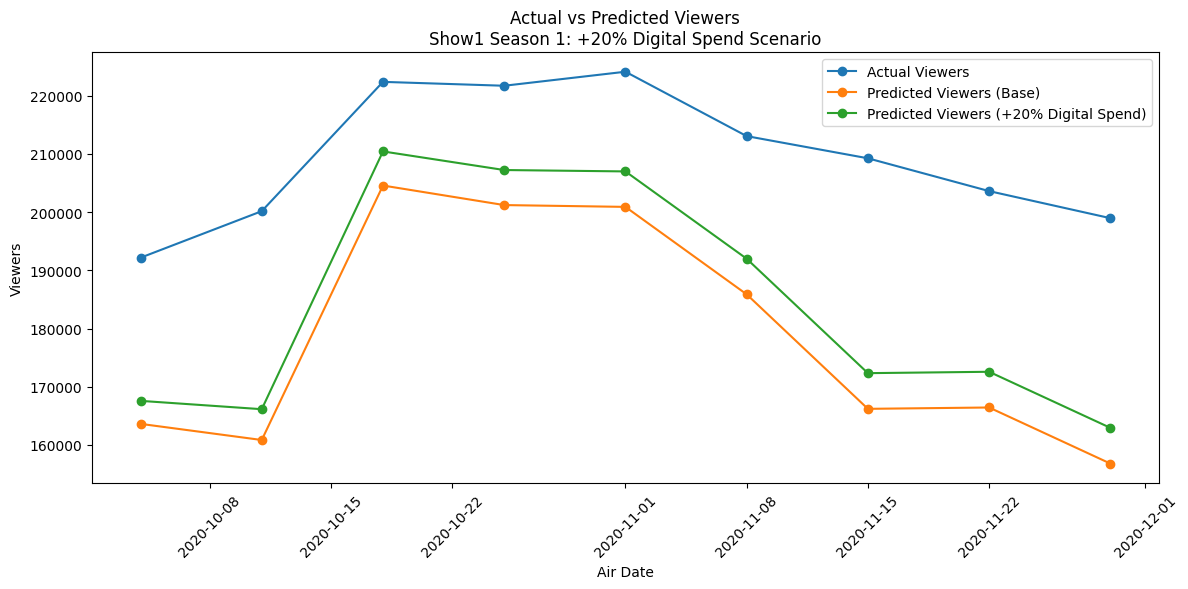


SUMMARY METRICS
--------------------------------------------------
Total predicted viewers (base): 1,606,410
Total predicted viewers (+20% digital): 1,658,180
Incremental viewers: 51,769
Predicted lift: 3.22%

Note: Because adstock carries media effects forward, the impact of the digital spend increase may continue beyond the selected end date.


In [543]:
# BONUS SIMULATION: +20% DIGITAL SPEND FOR A GIVEN PERIOD
# Uses the already fitted final model: model_sat
# Assumes:
# - gold_model_df is the original modeling dataset
# - theta_network, theta_cable, theta_digital are best theta values
# - apply_groupwise_adstock() is already defined
# - model_sat is already fitted on the final saturation model


# ------------------------------------------------------------
# 1. Choose simulation period
# ------------------------------------------------------------
sim_show = "Show1"
sim_season = 1
start_date = "2020-10-01"
end_date = "2020-11-30"


# ------------------------------------------------------------
# 2. Create baseline transformed dataset
#    (best adstock + saturation, no spend change)
# ------------------------------------------------------------
df_base = gold_model_df.copy()

# Ensure proper datetime and ordering
df_base["Air_Date"] = pd.to_datetime(df_base["Air_Date"])
df_base = df_base.sort_values(["Show", "Season", "Air_Date"]).reset_index(drop=True)

# Apply best adstock
df_base = apply_groupwise_adstock(
    df_base,
    theta_network=theta_network,
    theta_cable=theta_cable,
    theta_digital=theta_digital
)

# Apply same saturation logic used in final model
df_base["Network_TV_Sat"] = np.log1p(df_base["Network_TV_Adstock"])
df_base["Cable_TV_Sat"] = np.log1p(df_base["Cable_TV_Adstock"])
df_base["Digital_Sat"] = np.log1p(df_base["Digital_Adstock"])


# ------------------------------------------------------------
# 3. Create simulation dataset and increase only Digital spend
# ------------------------------------------------------------
df_sim = gold_model_df.copy()

# Ensure proper datetime and ordering
df_sim["Air_Date"] = pd.to_datetime(df_sim["Air_Date"])
df_sim = df_sim.sort_values(["Show", "Season", "Air_Date"]).reset_index(drop=True)

# Define selected simulation period
period_mask = (
    (df_sim["Show"] == sim_show) &
    (df_sim["Season"] == sim_season) &
    (df_sim["Air_Date"] >= start_date) &
    (df_sim["Air_Date"] <= end_date)
)

# Increase Digital spend by 20% only for selected weeks
df_sim.loc[period_mask, "Digital_Spend"] = df_sim.loc[period_mask, "Digital_Spend"] * 1.20

# Recompute adstock after spend change
df_sim = apply_groupwise_adstock(
    df_sim,
    theta_network=theta_network,
    theta_cable=theta_cable,
    theta_digital=theta_digital
)

# Recompute saturation after updated adstock
df_sim["Network_TV_Sat"] = np.log1p(df_sim["Network_TV_Adstock"])
df_sim["Cable_TV_Sat"] = np.log1p(df_sim["Cable_TV_Adstock"])
df_sim["Digital_Sat"] = np.log1p(df_sim["Digital_Adstock"])


# ------------------------------------------------------------
# 4. Predict baseline vs simulated using fitted saturation model
# ------------------------------------------------------------
features_sat = [
    "Network_TV_Sat",
    "Cable_TV_Sat",
    "Digital_Sat",
    "Holiday",
    "LeadIn_Bonus",
    "Episode_Type_PreLaunch",
    "Episode_Type_Premiere",
    "Episode_Type_Finale",
    "Week_Number"
]

df_base["Predicted_Viewers_Base"] = model_sat.predict(df_base[features_sat])
df_sim["Predicted_Viewers_Sim"] = model_sat.predict(df_sim[features_sat])


# ------------------------------------------------------------
# 5. Extract selected period for reporting and plotting
# ------------------------------------------------------------
plot_mask_base = (
    (df_base["Show"] == sim_show) &
    (df_base["Season"] == sim_season) &
    (df_base["Air_Date"] >= start_date) &
    (df_base["Air_Date"] <= end_date)
)

plot_mask_sim = (
    (df_sim["Show"] == sim_show) &
    (df_sim["Season"] == sim_season) &
    (df_sim["Air_Date"] >= start_date) &
    (df_sim["Air_Date"] <= end_date)
)

plot_df = df_base.loc[
    plot_mask_base,
    ["Air_Date", "True_Viewership", "Predicted_Viewers_Base"]
].copy()

plot_df["Predicted_Viewers_Sim"] = df_sim.loc[
    plot_mask_sim, "Predicted_Viewers_Sim"
].values

plot_df["Incremental_Viewers"] = (
    plot_df["Predicted_Viewers_Sim"] - plot_df["Predicted_Viewers_Base"]
)


# ------------------------------------------------------------
# 6. Show simulation table
# ------------------------------------------------------------
print("SIMULATION RESULTS FOR SELECTED PERIOD")
print("-" * 50)
print(plot_df[
    [
        "Air_Date",
        "True_Viewership",
        "Predicted_Viewers_Base",
        "Predicted_Viewers_Sim",
        "Incremental_Viewers"
    ]
])


# ------------------------------------------------------------
# 7. Plot actual vs baseline predicted vs simulated predicted
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    plot_df["Air_Date"],
    plot_df["True_Viewership"],
    marker="o",
    label="Actual Viewers"
)

plt.plot(
    plot_df["Air_Date"],
    plot_df["Predicted_Viewers_Base"],
    marker="o",
    label="Predicted Viewers (Base)"
)

plt.plot(
    plot_df["Air_Date"],
    plot_df["Predicted_Viewers_Sim"],
    marker="o",
    label="Predicted Viewers (+20% Digital Spend)"
)

plt.title(
    f"Actual vs Predicted Viewers\n"
    f"{sim_show} Season {sim_season}: +20% Digital Spend Scenario"
)
plt.xlabel("Air Date")
plt.ylabel("Viewers")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Summary metrics for selected period
# ------------------------------------------------------------
total_base = plot_df["Predicted_Viewers_Base"].sum()
total_sim = plot_df["Predicted_Viewers_Sim"].sum()
incremental = total_sim - total_base
pct_lift = (incremental / total_base) * 100 if total_base != 0 else np.nan

print("\nSUMMARY METRICS")
print("-" * 50)
print(f"Total predicted viewers (base): {total_base:,.0f}")
print(f"Total predicted viewers (+20% digital): {total_sim:,.0f}")
print(f"Incremental viewers: {incremental:,.0f}")
print(f"Predicted lift: {pct_lift:.2f}%")


# ------------------------------------------------------------
# 9. Optional note
# ------------------------------------------------------------
print(
    "\nNote: Because adstock carries media effects forward, the impact of the "
    "digital spend increase may continue beyond the selected end date."
)

#Increasing digital spend by 20% during the selected period is expected to increase total predicted viewership from about 1.61 million to 1.66 million, resulting in an incremental gain of roughly 52K viewers (around 3.2% lift). The gradual uplift across weeks suggests that digital marketing contributes through carryover effects rather than sharp immediate spikes. This indicates that higher digital investment can generate steady but moderate growth in audience reach. However, the incremental benefit should be evaluated against the additional marketing cost, as rising spend levels may reduce efficiency due to diminishing returns even when total viewership improves.

#Optimization

#Step 1: Starting with the baseline media allocation based on actual historical marketing spend.

#Step 2:Then I Reallocate raw media budget by shifting a chosen percentage of spend between marketing channels while keeping the total budget constant.

#Step 3: Recompute the adstock transformation to capture the carryover effect of advertising over time.

#Step 4: Apply the saturation transformation to model diminishing returns from increased media investment.

#Step 5: Prepare the final model input features, including transformed media variables, contextual indicators, and episode lifecycle controls.

#Step 6: Use the fitted Marketing Mix Model to predict viewership under the new allocation scenario.

#Step 7: Convert predicted viewership into estimated revenue using the global average revenue-per-viewer factor.

#Step 8: Compare each scenario’s predicted performance against the baseline using viewer lift and revenue lift metrics.

#Step 9: Identify the optimal media allocation strategy that maximizes predicted revenue.

In [544]:
gold_df.head()
#printing first few rows

,Show,Season,Week_Number,Air_Date,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus,Total_Spend
0,Show1,1,1,2020-09-06,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0,26183.935078
1,Show1,1,2,2020-09-13,0,PreLaunch,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0,31551.995313
2,Show1,1,3,2020-09-20,0,PreLaunch,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429,0,0,34907.946869
3,Show1,1,4,2020-09-27,0,PreLaunch,7619.321690,22857.965070,19048.304225,82542651,178971.843013,124396.604286,0,0,49525.590985
4,Show1,1,5,2020-10-04,0,PreLaunch,7133.216268,21399.648804,17833.040670,77276510,192167.775786,131526.194286,0,0,46365.905742


In [545]:
opt_df = gold_df.copy()
#creating a copy

#Reallocation function

In [546]:
def reallocate_budget(df, shift_from, shift_to, pct_shift):
   # Copy dataset
    temp = df.copy()

    # Calculate budget shift
    shift_amount = temp[shift_from] * pct_shift
    # Reduce source spend
    temp[shift_from] = temp[shift_from] - shift_amount
     # Increase target spend
    temp[shift_to] = temp[shift_to] + shift_amount

    # Return updated data
    return temp

#Features

In [547]:
features_sat = [
    "Network_TV_Sat",
    "Cable_TV_Sat",
    "Digital_Sat",
    "Holiday",
    "LeadIn_Bonus",
    "Episode_Type_PreLaunch",
    "Episode_Type_Premiere",
    "Episode_Type_Finale",
    "Week_Number"
]
#select features

#Rebuild Adstock + Saturation

In [548]:
def rebuild_model_inputs(df):
    temp = df.copy()

    # Ensure proper date format and sorting
    temp["Air_Date"] = pd.to_datetime(temp["Air_Date"])
    temp = temp.sort_values(["Show", "Season", "Air_Date"]).copy()

    # Recompute adstock by Show-Season
    temp["Network_TV_Adstock"] = (
        temp.groupby(["Show", "Season"])["Network_TV_Spend"]
        .transform(lambda x: geometric_adstock(x, 0.8))
    )

    temp["Cable_TV_Adstock"] = (
        temp.groupby(["Show", "Season"])["Cable_TV_Spend"]
        .transform(lambda x: geometric_adstock(x, 0.8))
    )

    temp["Digital_Adstock"] = (
        temp.groupby(["Show", "Season"])["Digital_Spend"]
        .transform(lambda x: geometric_adstock(x, 0.4))
    )

    # Apply same saturation used in final model
    temp["Network_TV_Sat"] = np.log1p(temp["Network_TV_Adstock"])
    temp["Cable_TV_Sat"] = np.log1p(temp["Cable_TV_Adstock"])
    temp["Digital_Sat"] = np.log1p(temp["Digital_Adstock"])

    # Recreate episode type dummies
    episode_dummies = pd.get_dummies(temp["Episode_Type"], prefix="Episode_Type")
    temp = pd.concat([temp, episode_dummies], axis=1)

    # Ensure all required dummy columns exist
    required_dummies = [
        "Episode_Type_PreLaunch",
        "Episode_Type_Premiere",
        "Episode_Type_Finale"
    ]

    for col in required_dummies:
        if col not in temp.columns:
            temp[col] = 0

    return temp

#baseline prediction

In [549]:
# Step 1 — Compute global revenue per viewer
avg_revenue_per_viewer = (
    gold_df["Revenue"].sum() /
    gold_df["True_Viewership"].sum()
)

print("Global Avg Revenue per Viewer:", avg_revenue_per_viewer)


# Step 2 — Baseline prediction pipeline
baseline_df = rebuild_model_inputs(gold_df)

X_baseline = baseline_df[features_sat]
baseline_df["Predicted_Viewers"] = model_sat.predict(X_baseline)

baseline_viewers = baseline_df["Predicted_Viewers"].sum()

baseline_revenue = baseline_viewers * avg_revenue_per_viewer

print("Baseline Viewers:", baseline_viewers)
print("Baseline Revenue:", baseline_revenue)

Global Avg Revenue per Viewer: 0.7009885716870377
Baseline Viewers: 51505881.66269462
Baseline Revenue: 36105034.420213886


In [550]:
# Store scenario outputs
scenario_results = []

# Define shift levels
pct_list = [0.05, 0.10, 0.15, 0.20]

# Define channel reallocation scenarios
scenario_pairs = [
    ("Digital_Spend", "Network_TV_Spend", "Digital → Network"),
    ("Digital_Spend", "Cable_TV_Spend", "Digital → Cable"),
    ("Network_TV_Spend", "Digital_Spend", "Network → Digital"),
    ("Cable_TV_Spend", "Digital_Spend", "Cable → Digital")
]


# Run optimization scenarios
for shift_from, shift_to, scenario_name in scenario_pairs:
    for pct in pct_list:

        # Step 1: Reallocate raw spend
        scenario_df = reallocate_budget(gold_df, shift_from, shift_to, pct)

        # Step 2: Rebuild transformed model inputs
        scenario_df = rebuild_model_inputs(scenario_df)

        # Step 3: Predict viewers
        X_scenario = scenario_df[features_sat]
        scenario_df["Predicted_Viewers"] = model_sat.predict(X_scenario)

        # Optional: predicted revenue at row level
        scenario_df["Predicted_Revenue"] = (
            scenario_df["Predicted_Viewers"] * avg_revenue_per_viewer
        )

        # Step 4: Aggregate scenario totals
        scenario_viewers = scenario_df["Predicted_Viewers"].sum()
        scenario_revenue = scenario_df["Predicted_Revenue"].sum()

        incremental_viewers = scenario_viewers - baseline_viewers
        incremental_revenue = scenario_revenue - baseline_revenue
        viewer_lift_pct = (incremental_viewers / baseline_viewers) * 100
        revenue_lift_pct = (incremental_revenue / baseline_revenue) * 100


        # Store scenario metrics
        scenario_results.append({
            "Scenario": scenario_name,
            "Shift_Pct": pct * 100,
            "Predicted_Viewers": scenario_viewers,
            "Predicted_Revenue": scenario_revenue,
            "Incremental_Viewers": incremental_viewers,
            "Incremental_Revenue": incremental_revenue,
            "Viewer_Lift_Pct": viewer_lift_pct,
            "Revenue_Lift_Pct": revenue_lift_pct
        })

In [551]:
# Create results table
results_df = pd.DataFrame(scenario_results)

# Rank scenarios by revenue
results_df = results_df.sort_values(
    by="Predicted_Revenue",
    ascending=False
)

# Display optimization results
results_df

,Scenario,Shift_Pct,Predicted_Viewers,Predicted_Revenue,Incremental_Viewers,Incremental_Revenue,Viewer_Lift_Pct,Revenue_Lift_Pct
3,Digital → Network,20.0,5.366862e+07,3.762109e+07,2.162735e+06,1.516053e+06,4.199006,4.199006
7,Digital → Cable,20.0,5.337957e+07,3.741847e+07,1.873688e+06,1.313434e+06,3.637813,3.637813
2,Digital → Network,15.0,5.336189e+07,3.740608e+07,1.856013e+06,1.301044e+06,3.603497,3.603497
6,Digital → Cable,15.0,5.312748e+07,3.724175e+07,1.621595e+06,1.136719e+06,3.148368,3.148368
1,Digital → Network,10.0,5.291059e+07,3.708972e+07,1.404704e+06,9.846814e+05,2.727269,2.727269
5,Digital → Cable,10.0,5.274023e+07,3.697030e+07,1.234345e+06,8.652615e+05,2.396512,2.396512
0,Digital → Network,5.0,5.229976e+07,3.666154e+07,7.938811e+05,5.565015e+05,1.541341,1.541341
4,Digital → Cable,5.0,5.220599e+07,3.659580e+07,7.001071e+05,4.907671e+05,1.359276,1.359276
12,Cable → Digital,5.0,5.127905e+07,3.594603e+07,-2.268267e+05,-1.590029e+05,-0.440390,-0.440390
8,Network → Digital,5.0,5.125212e+07,3.592715e+07,-2.537650e+05,-1.778863e+05,-0.492691,-0.492691


#Business Interpretation from Media Spend Optimization

#The scenario analysis shows that shifting a portion of marketing budget from Digital to TV channels could lead to better campaign outcomes. The biggest improvement is seen when spend is moved from Digital to Network TV, where predicted viewership and revenue increase by roughly 4–4.2% when 20% of the budget is reallocated. Moving budget from Digital to Cable TV also improves performance, although the gains are slightly smaller.

#This pattern suggests that TV channels may currently be generating stronger incremental impact, while Digital campaigns might already be closer to their effective spend limits in some situations. On the other hand, shifting budget away from TV toward Digital consistently reduces predicted performance, indicating that additional Digital investment may not translate into proportional audience growth at current spend levels.

#Overall, the findings indicate that slightly increasing the share of TV — especially Network TV — in the media mix could help improve campaign effectiveness, though the improvements are gradual rather than dramatic.

#Going forward, media allocation decisions can become more precise by analysing differences across shows and episode lifecycle stages, since channel performance is likely to vary depending on audience engagement, timing, and promotional strategy.

#Assumptions
#1.Linear Marketing Response within Observed Range:

#The baseline model assumes a linear relationship between marketing spend and viewership within the range of observed campaign investments. This implies that incremental changes in spend generate proportional changes in audience reach over the studied period.

#2.Baseline Performance Captures Unobserved Effects:

#In line with the case study, unobserved factors such as genre, competition, and audience preferences are assumed to contribute to underlying show performance, though the current model does not explicitly isolate all such effects.

#3.Episode Lifecycle as Relative Performance Measure:

#Episode lifecycle stages (Pre-Launch, Premiere, Finale) are interpreted relative to Regular episodes, which serve as the reference category. This assumes that lifecycle effects represent deviations from typical episode performance rather than independent drivers of viewership.


#4.Short-Term Demand Stability:

#The model assumes that underlying audience demand does not change abruptly within short time windows beyond what is captured through observed weekly trends and contextual indicators.

#5.Regression Assumption:Results should be interpreted as directional and decision-supportive rather than strictly causal, given omitted variables and the simplified regression structure.

#1.Methodological Choices
#Regression-Based Marketing Mix Modeling Framework

#A multiple linear regression approach was used as the foundational modeling framework due to its transparency, interpretability, and suitability for estimating marginal media effects in structured campaign data.

#2.Retaining Spend Variables in Original Dollar Scale

#Marketing spend variables were not standardized in order to maintain direct business interpretability of coefficients. This enables stakeholders to translate model outputs into actionable budget allocation decisions.

#3.Dummy Variable Encoding and Reference Category Selection

#Categorical episode lifecycle variables were converted into dummy indicators, with Regular episodes intentionally excluded to avoid multicollinearity. This allows coefficient estimates to represent performance differences relative to the baseline episode type.

#4.Modeling Advertising Carryover through Adstock

#Geometric adstock transformations were applied to media spend variables to capture delayed and cumulative advertising effects. Multiple decay parameters were tested systematically, and optimal values were selected based on out-of-sample predictive performance.

#5.Chronological Validation Strategy

#A time-aware train–test split was implemented within each Show–Season series. Earlier weeks were used for model estimation and later weeks for validation to preserve temporal structure and prevent information leakage from future observations.

#6.Incorporating Non-Linear Media Response (Saturation)

#To reflect diminishing marginal returns at higher investment levels, saturation transformations were evaluated on adstocked media variables. This methodological extension enhances behavioral realism in modeling advertising response.

#7.Model Performance Evaluation and Diagnostic Checks

#Model comparison was conducted using out-of-sample metrics including R², RMSE, and MAE. Multicollinearity diagnostics such as Variance Inflation Factor (VIF) were also assessed to ensure robustness and interpretability of coefficient estimates.

#Process followed:

#A stepwise regression-based MMM approach was followed to improve model realism and performance.

#Initial OLS Regression: Used for basic inference and to understand relationships between media spend and viewership.

#Baseline Regression Model: Plain multiple regression with raw spend variables to establish benchmark performance.

#Adstock Model: Geometric adstock was introduced to capture advertising carryover effects.

#Adstock Tuning: Multiple decay values were manually tested to identify the best-performing adstock parameters with show season split.

#Adstock + Saturation Model: Saturation transformation was applied to capture diminishing returns at higher spend levels again with show season split.

#Model Comparison: Models were compared using out-of-sample metrics such as R², RMSE, and MAE to select the most appropriate specification.

#We intentionally moved from a simple baseline model to progressively more realistic transformed models

#As a next step, the pipeline can be made more automated and dependable so the process is easier to repeat with new data. Adding validation checks for duplicates, missing values, and correct weekly aggregation would make the Silver-to-Gold flow much more robust and reduce the chance of manual errors. From a modeling perspective, future work can build on the current approach by introducing stronger baseline controls, better lag assumptions, and potentially Bayesian MMM to better reflect uncertainty and show-level differences. In the long run, this would turn the current case study into a practical decision-making pipeline that supports regular campaign reporting, media optimization, and smarter budget planning.